In [6]:
import pandas as pd
import os
import urllib
from sqlalchemy import create_engine

In [7]:
begin_inventory = pd.read_csv("begin_inventory.csv")
end_inventory = pd.read_csv("end_inventory.csv")
purchase_prices = pd.read_csv("purchase_prices.csv")
purchases = pd.read_csv("purchases.csv")
sales = pd.read_csv("sales.csv")
vendor_invoice = pd.read_csv("vendor_invoice.csv")

print("All 6 CSV files loaded successfully!")

All 6 CSV files loaded successfully!


In [8]:
print("begin_inventory:", begin_inventory.shape)
print("end_inventory:", end_inventory.shape)
print("purchase_prices:", purchase_prices.shape)
print("purchases:", purchases.shape)
print("sales:", sales.shape)
print("vendor_invoice:", vendor_invoice.shape)

begin_inventory: (206529, 9)
end_inventory: (224489, 9)
purchase_prices: (12261, 9)
purchases: (2372474, 16)
sales: (12825363, 14)
vendor_invoice: (5543, 10)


In [9]:
server = r"HIMANSHU\SQLEXPRESS"
database = "VendorPerformanceDB"
driver = "ODBC Driver 18 for SQL Server"

connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

params = urllib.parse.quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

print("SQL Server engine created successfully!")

SQL Server engine created successfully!


In [10]:
with engine.connect() as connection:
    print("Connected to VendorPerformanceDB successfully!")

Connected to VendorPerformanceDB successfully!


In [11]:
begin_inventory.to_sql(
    "begin_inventory",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000
)

print("begin_inventory uploaded successfully!")
print("Records uploaded:", len(begin_inventory))

begin_inventory uploaded successfully!
Records uploaded: 206529


In [12]:
end_inventory.to_sql(
    "end_inventory",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000
)

print("end_inventory uploaded successfully!")
print("Records uploaded:", len(end_inventory))

end_inventory uploaded successfully!
Records uploaded: 224489


In [13]:
purchase_prices.to_sql(
    "purchase_prices",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000
)

print("purchase_prices uploaded successfully!")
print("Records uploaded:", len(purchase_prices))

purchase_prices uploaded successfully!
Records uploaded: 12261


In [14]:
purchases.to_sql(
    "purchases",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=10000
)

print("purchases uploaded successfully!")
print("Records uploaded:", len(purchases))

purchases uploaded successfully!
Records uploaded: 2372474


In [15]:
sales.to_sql(
    "sales",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=10000
)

print("sales uploaded successfully!")
print("Records uploaded:", len(sales))

sales uploaded successfully!
Records uploaded: 12825363


In [16]:
 vendor_invoice.to_sql(
    "vendor_invoice",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000
)

print("vendor_invoice uploaded successfully!")
print("Records uploaded:", len(vendor_invoice))

vendor_invoice uploaded successfully!
Records uploaded: 5543


In [17]:
query = """
SELECT 
    t.name AS table_name,
    SUM(p.rows) AS row_count
FROM sys.tables t
INNER JOIN sys.partitions p
    ON t.object_id = p.object_id
WHERE p.index_id IN (0, 1)
GROUP BY t.name
ORDER BY t.name;
"""

tables_df = pd.read_sql(query, engine)

display(tables_df)

,table_name,row_count
0,begin_inventory,206529
1,end_inventory,224489
2,purchase_prices,12261
3,purchases,2372474
4,sales,12825363
5,vendor_invoice,5543


In [18]:
query = """
SELECT 
    TABLE_NAME,
    COLUMN_NAME,
    DATA_TYPE
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_NAME IN (
    'begin_inventory',
    'end_inventory',
    'purchase_prices',
    'purchases',
    'sales',
    'vendor_invoice'
)
ORDER BY TABLE_NAME, ORDINAL_POSITION;
"""

columns_df = pd.read_sql(query, engine)

display(columns_df)

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,begin_inventory,InventoryId,varchar
1,begin_inventory,Store,bigint
2,begin_inventory,City,varchar
3,begin_inventory,Brand,bigint
4,begin_inventory,Description,varchar
...,...,...,...
62,vendor_invoice,PayDate,varchar
63,vendor_invoice,Quantity,bigint
64,vendor_invoice,Dollars,float
65,vendor_invoice,Freight,float


In [19]:
for table in [
    "begin_inventory",
    "end_inventory",
    "purchase_prices",
    "purchases",
    "sales",
    "vendor_invoice"
]:
    
    print("\n" + "=" * 60)
    print(f"TABLE: {table}")
    print("=" * 60)
    
    query = f"""
    SELECT 
        COLUMN_NAME,
        DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = '{table}'
    ORDER BY ORDINAL_POSITION;
    """
    
    display(pd.read_sql(query, engine))


TABLE: begin_inventory


,COLUMN_NAME,DATA_TYPE
0,InventoryId,varchar
1,Store,bigint
2,City,varchar
3,Brand,bigint
4,Description,varchar
5,Size,varchar
6,onHand,bigint
7,Price,float
8,startDate,varchar



TABLE: end_inventory


,COLUMN_NAME,DATA_TYPE
0,InventoryId,varchar
1,Store,bigint
2,City,varchar
3,Brand,bigint
4,Description,varchar
5,Size,varchar
6,onHand,bigint
7,Price,float
8,endDate,varchar



TABLE: purchase_prices


...

,COLUMN_NAME,DATA_TYPE
0,InventoryId,varchar
1,Store,bigint
2,Brand,bigint
3,Description,varchar
4,Size,varchar
5,VendorNumber,bigint
6,VendorName,varchar
7,PONumber,bigint
8,PODate,varchar
9,ReceivingDate,varchar



TABLE: sales


,COLUMN_NAME,DATA_TYPE
0,InventoryId,varchar
1,Store,bigint
2,Brand,bigint
3,Description,varchar
4,Size,varchar
5,SalesQuantity,bigint
6,SalesDollars,float
7,SalesPrice,float
8,SalesDate,varchar
9,Volume,float



TABLE: vendor_invoice


,COLUMN_NAME,DATA_TYPE
0,VendorNumber,bigint
1,VendorName,varchar
2,InvoiceDate,varchar
3,PONumber,bigint
4,PODate,varchar
5,PayDate,varchar
6,Quantity,bigint
7,Dollars,float
8,Freight,float
9,Approval,varchar


In [20]:
tables = [
    "begin_inventory",
    "end_inventory",
    "purchase_prices",
    "purchases",
    "sales",
    "vendor_invoice"
]

for table in tables:
    query = f"""
    SELECT COLUMN_NAME
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = '{table}'
    ORDER BY ORDINAL_POSITION;
    """
    
    columns = pd.read_sql(query, engine)["COLUMN_NAME"].tolist()
    
    print("\n" + "=" * 60)
    print(f"{table}")
    print("=" * 60)
    
    for i, column in enumerate(columns, 1):
        print(f"{i}. {column}")


begin_inventory
1. InventoryId
2. Store
3. City
4. Brand
5. Description
6. Size
7. onHand
8. Price
9. startDate

end_inventory
1. InventoryId
2. Store
3. City
4. Brand
5. Description
6. Size
7. onHand
8. Price
9. endDate

purchase_prices
1. Brand
2. Description
3. Price
4. Size
5. Volume
6. Classification
7. PurchasePrice
8. VendorNumber
9. VendorName

purchases
1. InventoryId
2. Store
3. Brand
4. Description
5. Size
6. VendorNumber
7. VendorName
8. PONumber
9. PODate
10. ReceivingDate
11. InvoiceDate
12. PayDate
13. PurchasePrice
14. Quantity
15. Dollars
16. Classification

sales
1. InventoryId
2. Store
3. Brand
4. Description
5. Size
6. SalesQuantity
7. SalesDollars
8. SalesPrice
9. SalesDate
10. Volume
11. Classification
12. ExciseTax
13. VendorNo
14. VendorName

vendor_invoice
1. VendorNumber
2. VendorName
3. InvoiceDate
4. PONumber
5. PODate
6. PayDate
7. Quantity
8. Dollars
9. Freight
10. Approval


In [21]:
tables = [
    "begin_inventory",
    "end_inventory",
    "purchase_prices",
    "purchases",
    "sales",
    "vendor_invoice"
]

for table in tables:
    query = f"""
    SELECT COLUMN_NAME
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = '{table}'
    ORDER BY ORDINAL_POSITION;
    """
    
    columns = pd.read_sql(query, engine)["COLUMN_NAME"].tolist()
    
    print(f"\n{table}:")
    print(" | ".join(columns))


begin_inventory:
InventoryId | Store | City | Brand | Description | Size | onHand | Price | startDate

end_inventory:
InventoryId | Store | City | Brand | Description | Size | onHand | Price | endDate

purchase_prices:
Brand | Description | Price | Size | Volume | Classification | PurchasePrice | VendorNumber | VendorName

purchases:
InventoryId | Store | Brand | Description | Size | VendorNumber | VendorName | PONumber | PODate | ReceivingDate | InvoiceDate | PayDate | PurchasePrice | Quantity | Dollars | Classification

sales:
InventoryId | Store | Brand | Description | Size | SalesQuantity | SalesDollars | SalesPrice | SalesDate | Volume | Classification | ExciseTax | VendorNo | VendorName

vendor_invoice:
VendorNumber | VendorName | InvoiceDate | PONumber | PODate | PayDate | Quantity | Dollars | Freight | Approval


In [22]:
query = """
SELECT
    'purchases' AS table_name,
    COUNT(*) AS total_rows,
    COUNT(DISTINCT InventoryId) AS unique_inventory_ids,
    COUNT(DISTINCT VendorNumber) AS unique_vendors
FROM purchases

UNION ALL

SELECT
    'sales',
    COUNT(*),
    COUNT(DISTINCT InventoryId),
    COUNT(DISTINCT VendorNo)
FROM sales

UNION ALL

SELECT
    'purchase_prices',
    COUNT(*),
    COUNT(DISTINCT Brand),
    COUNT(DISTINCT VendorNumber)
FROM purchase_prices

UNION ALL

SELECT
    'vendor_invoice',
    COUNT(*),
    COUNT(DISTINCT PONumber),
    COUNT(DISTINCT VendorNumber)
FROM vendor_invoice

UNION ALL

SELECT
    'begin_inventory',
    COUNT(*),
    COUNT(DISTINCT InventoryId),
    COUNT(DISTINCT Brand)
FROM begin_inventory

UNION ALL

SELECT
    'end_inventory',
    COUNT(*),
    COUNT(DISTINCT InventoryId),
    COUNT(DISTINCT Brand)
FROM end_inventory;
"""

relationship_check = pd.read_sql(query, engine)

display(relationship_check)

,table_name,total_rows,unique_inventory_ids,unique_vendors
0,purchases,2372474,245907,126
1,sales,12825363,267552,127
2,purchase_prices,12261,12261,131
3,vendor_invoice,5543,5543,126
4,begin_inventory,206529,206529,8094
5,end_inventory,224489,224489,9653


In [23]:
tables = [
    "begin_inventory",
    "end_inventory",
    "purchase_prices",
    "purchases",
    "sales",
    "vendor_invoice"
]

for table in tables:
    
    query = f"""
    SELECT
        COLUMN_NAME,
        SUM(
            CASE 
                WHEN [{table}].[COLUMN_NAME] IS NULL THEN 1
                ELSE 0
            END
        ) AS null_count
    FROM [{table}]
    """

In [24]:
for table in tables:
    
    columns_query = f"""
    SELECT COLUMN_NAME
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = '{table}'
    ORDER BY ORDINAL_POSITION;
    """
    
    columns = pd.read_sql(columns_query, engine)["COLUMN_NAME"].tolist()
    
    null_checks = ", ".join(
        [
            f"SUM(CASE WHEN [{col}] IS NULL THEN 1 ELSE 0 END) AS [{col}]"
            for col in columns
        ]
    )
    
    query = f"""
    SELECT {null_checks}
    FROM [{table}];
    """
    
    result = pd.read_sql(query, engine)
    
    print("\n" + "=" * 70)
    print(f"NULL VALUES — {table}")
    print("=" * 70)
    
    # Show only columns having NULL values
    null_columns = result.T
    null_columns.columns = ["null_count"]
    null_columns = null_columns[null_columns["null_count"] > 0]
    
    if null_columns.empty:
        print("No NULL values found.")
    else:
        display(null_columns)


NULL VALUES — begin_inventory
No NULL values found.

NULL VALUES — end_inventory


,null_count
City,1284



NULL VALUES — purchase_prices


,null_count
Description,1
Size,1
Volume,1



NULL VALUES — purchases


,null_count
Size,3



NULL VALUES — sales
No NULL values found.

NULL VALUES — vendor_invoice


,null_count
Approval,5169


In [25]:
for table in tables:
    
    query = f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(*) - COUNT(DISTINCT row_hash) AS duplicate_rows
    FROM (
        SELECT
            HASHBYTES(
                'SHA2_256',
                CONCAT_WS('|',
                    {', '.join(
                        f"ISNULL(CAST([{col}] AS NVARCHAR(MAX)), 'NULL')"
                        for col in pd.read_sql(
                            f"SELECT COLUMN_NAME FROM INFORMATION_SCHEMA.COLUMNS "
                            f"WHERE TABLE_NAME = '{table}' "
                            f"ORDER BY ORDINAL_POSITION",
                            engine
                        )['COLUMN_NAME']
                    )}
                )
            ) AS row_hash
        FROM [{table}]
    ) AS hashed;
    """
    
    result = pd.read_sql(query, engine)
    
    print(f"\n{table}")
    print(result)


begin_inventory
   total_rows  duplicate_rows
0      206529               0

end_inventory
   total_rows  duplicate_rows
0      224489               0

purchase_prices
   total_rows  duplicate_rows
0       12261               0

purchases
   total_rows  duplicate_rows
0     2372474               0

sales
   total_rows  duplicate_rows
0    12825363               0

vendor_invoice
   total_rows  duplicate_rows
0        5543               0


In [26]:
query = """
SELECT *
FROM end_inventory
WHERE City IS NULL;
"""

end_nulls = pd.read_sql(query, engine)

display(end_nulls)

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,46__58,46,None,58,Gekkeikan Black & Gold Sake,750mL,0,12.99,2024-12-31
1,46__62,46,None,62,Herradura Silver Tequila,750mL,0,36.99,2024-12-31
2,46__63,46,None,63,Herradura Reposado Tequila,750mL,0,38.99,2024-12-31
3,46__77,46,None,77,Three Olives Espresso Vodka,750mL,0,14.99,2024-12-31
4,46__106,46,None,106,Mr Boston Peach Schnapps,Liter,0,4.49,2024-12-31
...,...,...,...,...,...,...,...,...,...
1279,46__46447,46,None,46447,Gascon Malbec Mendoza,750mL,0,10.99,2024-12-31
1280,46__46458,46,None,46458,Layer Cake Barosa Shiraz,750mL,0,15.99,2024-12-31
1281,46__46476,46,None,46476,Tilia Malbec Mendoza,750mL,0,9.99,2024-12-31
1282,46__46764,46,None,46764,Clayhouse Adobe Red Paso Rbl,750mL,0,11.99,2024-12-31


In [27]:
query = """
SELECT 
    Store,
    City,
    COUNT(*) AS record_count
FROM end_inventory
WHERE Store = 46
GROUP BY Store, City
ORDER BY record_count DESC;
"""

store_46_city = pd.read_sql(query, engine)

display(store_46_city)

,Store,City,record_count
0,46,None,1284


In [28]:
query = """
SELECT
    Store,
    City,
    COUNT(*) AS record_count
FROM begin_inventory
WHERE Store = 46
GROUP BY Store, City
ORDER BY record_count DESC;
"""

store_46_begin = pd.read_sql(query, engine)

display(store_46_begin)

,Store,City,record_count
0,46,TYWARDREATH,1880


In [29]:
query = """
SELECT
    Store,
    COUNT(DISTINCT City) AS unique_city_count
FROM begin_inventory
WHERE City IS NOT NULL
GROUP BY Store
HAVING COUNT(DISTINCT City) > 1
ORDER BY Store;
"""

multiple_cities = pd.read_sql(query, engine)

display(multiple_cities)

,Store,unique_city_count


In [30]:
query = """
SELECT *
FROM purchases
WHERE Size IS NULL;
"""

purchases_null_size = pd.read_sql(query, engine)

display(purchases_null_size)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,34_PITMERDEN_3121,34,3121,Pinnacle Rainbow Sherbet,None,12546,JIM BEAM BRANDS COMPANY,10938,2024-06-27,2024-07-04,2024-07-13,2024-08-16,6.93,7,48.51,1
1,34_PITMERDEN_5678,34,5678,Skinnygirl Pina Colada,None,12546,JIM BEAM BRANDS COMPANY,10938,2024-06-27,2024-07-09,2024-07-13,2024-08-16,6.93,6,41.58,1
2,39_EASTHALLOW_15365,39,15365,Alabaster 07 Tinta de Toro,None,9552,M S WALKER INC,10972,2024-06-29,2024-07-07,2024-07-13,2024-08-21,91.83,1,91.83,2


In [31]:
query = """
SELECT
    Brand,
    Description,
    VendorNumber,
    Size,
    Volume,
    PurchasePrice
FROM purchase_prices
WHERE
    (Brand = 3121 AND VendorNumber = 12546)
    OR
    (Brand = 5678 AND VendorNumber = 12546)
    OR
    (Brand = 15365 AND VendorNumber = 9552)
ORDER BY Brand;
"""

purchase_size_check = pd.read_sql(query, engine)

display(purchase_size_check)


,Brand,Description,VendorNumber,Size,Volume,PurchasePrice
0,3121,Pinnacle Rainbow Sherbet,12546,750mL,750,6.93
1,5678,Skinnygirl Pina Colada,12546,750mL,750,6.93
2,15365,Alabaster 07 Tinta de Toro,9552,750mL,750,91.83


In [32]:
query = """
SELECT *
FROM purchase_prices
WHERE Description IS NULL
   OR Size IS NULL
   OR Volume IS NULL;
"""

purchase_price_nulls = pd.read_sql(query, engine)

display(purchase_price_nulls)

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,4202,None,0.0,None,None,1,11.19,480,BACARDI USA INC


In [33]:
query = """
SELECT TOP 20
    InventoryId,
    Store,
    Brand,
    Description,
    Size,
    VendorNumber,
    VendorName,
    PurchasePrice,
    Quantity,
    Dollars
FROM purchases
WHERE Brand = 4202
  AND VendorNumber = 480
ORDER BY PurchasePrice;
"""

brand_4202_check = pd.read_sql(query, engine)

display(brand_4202_check)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PurchasePrice,Quantity,Dollars


In [36]:
query = """
SELECT TOP 20
    Brand,
    Description,
    Size,
    VendorNumber,
    VendorName,
    PurchasePrice,
    Quantity,
    Dollars
FROM purchases
WHERE Brand = 4202
  AND VendorNumber = 480
ORDER BY PurchasePrice;
"""

brand_4202_details = pd.read_sql(query, engine)

display(brand_4202_details)

,Brand,Description,Size,VendorNumber,VendorName,PurchasePrice,Quantity,Dollars


In [37]:
query = """
SELECT
    Approval,
    COUNT(*) AS record_count
FROM vendor_invoice
GROUP BY Approval
ORDER BY record_count DESC;
"""

approval_summary = pd.read_sql(query, engine)

display(approval_summary)

,Approval,record_count
0,None,5169
1,Frank Delahunt,374


In [38]:
query = """
SELECT
    VendorNumber,
    VendorName,
    SUM(Quantity) AS TotalPurchaseQuantity,
    SUM(Dollars) AS TotalPurchaseDollars,
    AVG(PurchasePrice) AS AveragePurchasePrice,
    COUNT(DISTINCT PONumber) AS TotalPurchaseOrders
FROM purchases
GROUP BY
    VendorNumber,
    VendorName
ORDER BY TotalPurchaseDollars DESC;
"""

vendor_purchase_summary = pd.read_sql(query, engine)

display(vendor_purchase_summary.head(10))

,VendorNumber,VendorName,TotalPurchaseQuantity,TotalPurchaseDollars,AveragePurchasePrice,TotalPurchaseOrders
0,3960,DIAGEO NORTH AMERICA INC,5459788,50959796.85,16.107171,55
1,4425,MARTIGNETTI COMPANIES,2640411,27861690.02,11.081386,82
2,12546,JIM BEAM BRANDS COMPANY,2737165,24203151.05,12.880280,55
3,17035,PERNOD RICARD USA,1647558,24124091.56,18.605831,55
4,480,BACARDI USA INC,1427075,17624378.72,14.256139,55
5,1392,CONSTELLATION BRANDS INC,2325892,15573917.90,7.096473,55
6,1128,BROWN-FORMAN CORP,1006122,13529433.08,18.298498,55
7,9165,ULTRA BEVERAGE COMPANY LLP,1077527,13210613.93,15.810002,55
8,3252,E & J GALLO WINERY,1858260,12289608.09,7.258303,55
9,9552,M S WALKER INC,1372841,10935817.30,8.680670,55


In [39]:
query = """
SELECT
    VendorNo AS VendorNumber,
    VendorName,
    SUM(SalesQuantity) AS TotalSalesQuantity,
    SUM(SalesDollars) AS TotalSalesDollars,
    AVG(SalesPrice) AS AverageSalesPrice,
    COUNT(DISTINCT Brand) AS UniqueBrandsSold
FROM sales
GROUP BY
    VendorNo,
    VendorName
ORDER BY TotalSalesDollars DESC;
"""

vendor_sales_summary = pd.read_sql(query, engine)

display(vendor_sales_summary.head(10))

,VendorNumber,VendorName,TotalSalesQuantity,TotalSalesDollars,AverageSalesPrice,UniqueBrandsSold
0,3960,DIAGEO NORTH AMERICA INC,5422703,6.874242e+07,17.487180,415
1,4425,MARTIGNETTI COMPANIES,2581318,4.104731e+07,17.087914,1495
2,17035,PERNOD RICARD USA,1613460,3.228125e+07,21.241544,254
3,12546,JIM BEAM BRANDS COMPANY,2630226,3.190632e+07,14.701625,389
4,480,BACARDI USA INC,1457301,2.501456e+07,16.504006,171
5,1392,CONSTELLATION BRANDS INC,2301688,2.446917e+07,11.183558,461
6,3252,E & J GALLO WINERY,1809023,1.855609e+07,11.062457,510
7,1128,BROWN-FORMAN CORP,983853,1.847856e+07,20.300100,135
8,9165,ULTRA BEVERAGE COMPANY LLP,1043235,1.782294e+07,19.178801,883
9,9552,M S WALKER INC,1343481,1.546525e+07,12.572729,882


In [40]:
query = """
SELECT
    VendorNumber,
    VendorName,
    SUM(Dollars) AS InvoiceDollars,
    SUM(Freight) AS TotalFreight,
    COUNT(DISTINCT PONumber) AS InvoicePOCount
FROM vendor_invoice
GROUP BY
    VendorNumber,
    VendorName
ORDER BY InvoiceDollars DESC;
"""

vendor_invoice_summary = pd.read_sql(query, engine)

display(vendor_invoice_summary.head(10))

,VendorNumber,VendorName,InvoiceDollars,TotalFreight,InvoicePOCount
0,3960,DIAGEO NORTH AMERICA INC,50959796.85,257032.07,55
1,4425,MARTIGNETTI COMPANIES,27861690.02,144929.24,82
2,12546,JIM BEAM BRANDS COMPANY,24203151.05,123880.97,55
3,17035,PERNOD RICARD USA,24124091.56,123780.22,55
4,480,BACARDI USA INC,17624378.72,89286.27,55
5,1392,CONSTELLATION BRANDS INC,15573917.90,79528.99,55
6,1128,BROWN-FORMAN CORP,13529433.08,68601.68,55
7,9165,ULTRA BEVERAGE COMPANY LLP,13210613.93,68054.70,55
8,3252,E & J GALLO WINERY,12289608.09,61966.91,55
9,9552,M S WALKER INC,10935817.30,55551.82,55


In [41]:
query = """
SELECT
    VendorNumber,
    VendorName,
    AVG(PurchasePrice) AS AvgListedPurchasePrice,
    COUNT(DISTINCT Brand) AS ProductCount
FROM purchase_prices
GROUP BY
    VendorNumber,
    VendorName
ORDER BY AvgListedPurchasePrice DESC;
"""

vendor_price_summary = pd.read_sql(query, engine)

display(vendor_price_summary.head(10))

,VendorNumber,VendorName,AvgListedPurchasePrice,ProductCount
0,2561,EDRINGTON AMERICAS,347.076667,33
1,11567,CAMPARI AMERICA,216.579865,74
2,8112,MOET HENNESSY USA INC,135.700465,129
3,54,AAPER ALCOHOL & CHEMICAL CO,105.070000,1
4,3664,WILLIAM GRANT & SONS INC,103.216235,85
5,7239,REMY COINTREAU USA INC,82.473556,45
6,8664,"STOLI GROUP,(USA) LLC",59.124375,48
7,1703,ALISA CARR BEVERAGES,58.115938,32
8,1587,VINEYARD BRANDS LLC,51.900000,3
9,2000,SOUTHERN GLAZERS W&S OF NE,48.474444,9


In [42]:
query = """
WITH vendor_list AS (
    SELECT DISTINCT VendorNumber
    FROM purchases

    UNION

    SELECT DISTINCT VendorNo AS VendorNumber
    FROM sales

    UNION

    SELECT DISTINCT VendorNumber
    FROM vendor_invoice

    UNION

    SELECT DISTINCT VendorNumber
    FROM purchase_prices
)

SELECT
    v.VendorNumber,

    CASE WHEN p.VendorNumber IS NOT NULL THEN 1 ELSE 0 END AS InPurchases,
    CASE WHEN s.VendorNo IS NOT NULL THEN 1 ELSE 0 END AS InSales,
    CASE WHEN i.VendorNumber IS NOT NULL THEN 1 ELSE 0 END AS InInvoice,
    CASE WHEN pp.VendorNumber IS NOT NULL THEN 1 ELSE 0 END AS InPurchasePrices

FROM vendor_list v

LEFT JOIN (
    SELECT DISTINCT VendorNumber
    FROM purchases
) p
    ON v.VendorNumber = p.VendorNumber

LEFT JOIN (
    SELECT DISTINCT VendorNo
    FROM sales
) s
    ON v.VendorNumber = s.VendorNo

LEFT JOIN (
    SELECT DISTINCT VendorNumber
    FROM vendor_invoice
) i
    ON v.VendorNumber = i.VendorNumber

LEFT JOIN (
    SELECT DISTINCT VendorNumber
    FROM purchase_prices
) pp
    ON v.VendorNumber = pp.VendorNumber

ORDER BY v.VendorNumber;
"""

vendor_coverage = pd.read_sql(query, engine)

display(vendor_coverage.head(20))

,VendorNumber,InPurchases,InSales,InInvoice,InPurchasePrices
0,2,1,1,1,1
1,54,1,0,1,1
2,60,1,1,1,1
3,105,1,1,1,1
4,200,1,1,1,1
5,287,1,1,1,1
6,388,1,1,1,1
7,480,1,1,1,1
8,516,1,1,1,1
9,653,1,1,1,1


In [43]:
query = """
WITH vendor_list AS (
    SELECT DISTINCT VendorNumber
    FROM purchases

    UNION

    SELECT DISTINCT VendorNo AS VendorNumber
    FROM sales

    UNION

    SELECT DISTINCT VendorNumber
    FROM vendor_invoice

    UNION

    SELECT DISTINCT VendorNumber
    FROM purchase_prices
),
coverage AS (
    SELECT
        v.VendorNumber,
        CASE WHEN p.VendorNumber IS NOT NULL THEN 1 ELSE 0 END AS InPurchases,
        CASE WHEN s.VendorNo IS NOT NULL THEN 1 ELSE 0 END AS InSales,
        CASE WHEN i.VendorNumber IS NOT NULL THEN 1 ELSE 0 END AS InInvoice,
        CASE WHEN pp.VendorNumber IS NOT NULL THEN 1 ELSE 0 END AS InPurchasePrices
    FROM vendor_list v

    LEFT JOIN (
        SELECT DISTINCT VendorNumber
        FROM purchases
    ) p ON v.VendorNumber = p.VendorNumber

    LEFT JOIN (
        SELECT DISTINCT VendorNo
        FROM sales
    ) s ON v.VendorNumber = s.VendorNo

    LEFT JOIN (
        SELECT DISTINCT VendorNumber
        FROM vendor_invoice
    ) i ON v.VendorNumber = i.VendorNumber

    LEFT JOIN (
        SELECT DISTINCT VendorNumber
        FROM purchase_prices
    ) pp ON v.VendorNumber = pp.VendorNumber
)

SELECT
    COUNT(*) AS TotalUniqueVendors,
    SUM(InPurchases) AS VendorsInPurchases,
    SUM(InSales) AS VendorsInSales,
    SUM(InInvoice) AS VendorsInInvoice,
    SUM(InPurchasePrices) AS VendorsInPurchasePrices,

    SUM(
        CASE
            WHEN InPurchases = 1
             AND InSales = 1
             AND InInvoice = 1
             AND InPurchasePrices = 1
            THEN 1 ELSE 0
        END
    ) AS VendorsInAllFour

FROM coverage;
"""

vendor_coverage_summary = pd.read_sql(query, engine)

display(vendor_coverage_summary)

,TotalUniqueVendors,VendorsInPurchases,VendorsInSales,VendorsInInvoice,VendorsInPurchasePrices,VendorsInAllFour
0,132,126,127,126,131,123


In [44]:
display(
    vendor_coverage_summary[
        [
            "TotalUniqueVendors",
            "VendorsInPurchases",
            "VendorsInSales",
            "VendorsInInvoice",
            "VendorsInPurchasePrices",
            "VendorsInAllFour"
        ]
    ].T
)

,0
TotalUniqueVendors,132
VendorsInPurchases,126
VendorsInSales,127
VendorsInInvoice,126
VendorsInPurchasePrices,131
VendorsInAllFour,123


In [45]:
query = """
SELECT
    p.VendorNumber,
    p.VendorName,

    -- Purchase Metrics
    p.TotalPurchaseQuantity,
    p.TotalPurchaseDollars,
    p.AveragePurchasePrice,
    p.TotalPurchaseOrders,

    -- Sales Metrics
    s.TotalSalesQuantity,
    s.TotalSalesDollars,
    s.AverageSalesPrice,
    s.UniqueBrandsSold,

    -- Invoice Metrics
    i.InvoiceDollars,
    i.TotalFreight,
    i.InvoicePOCount,

    -- Price Metrics
    pp.AvgListedPurchasePrice,
    pp.ProductCount,

    -- Business Metrics
    s.TotalSalesDollars - p.TotalPurchaseDollars AS GrossProfit,

    CASE
        WHEN s.TotalSalesDollars > 0
        THEN
            ((s.TotalSalesDollars - p.TotalPurchaseDollars)
            / s.TotalSalesDollars) * 100
        ELSE 0
    END AS ProfitMarginPercentage,

    CASE
        WHEN p.TotalPurchaseDollars > 0
        THEN
            (i.TotalFreight / p.TotalPurchaseDollars) * 100
        ELSE 0
    END AS FreightPercentage

FROM
(
    SELECT
        VendorNumber,
        VendorName,
        SUM(Quantity) AS TotalPurchaseQuantity,
        SUM(Dollars) AS TotalPurchaseDollars,
        AVG(PurchasePrice) AS AveragePurchasePrice,
        COUNT(DISTINCT PONumber) AS TotalPurchaseOrders
    FROM purchases
    GROUP BY VendorNumber, VendorName
) p

INNER JOIN
(
    SELECT
        VendorNo AS VendorNumber,
        VendorName,
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(SalesDollars) AS TotalSalesDollars,
        AVG(SalesPrice) AS AverageSalesPrice,
        COUNT(DISTINCT Brand) AS UniqueBrandsSold
    FROM sales
    GROUP BY VendorNo, VendorName
) s
    ON p.VendorNumber = s.VendorNumber

INNER JOIN
(
    SELECT
        VendorNumber,
        VendorName,
        SUM(Dollars) AS InvoiceDollars,
        SUM(Freight) AS TotalFreight,
        COUNT(DISTINCT PONumber) AS InvoicePOCount
    FROM vendor_invoice
    GROUP BY VendorNumber, VendorName
) i
    ON p.VendorNumber = i.VendorNumber

INNER JOIN
(
    SELECT
        VendorNumber,
        VendorName,
        AVG(PurchasePrice) AS AvgListedPurchasePrice,
        COUNT(DISTINCT Brand) AS ProductCount
    FROM purchase_prices
    GROUP BY VendorNumber, VendorName
) pp
    ON p.VendorNumber = pp.VendorNumber

ORDER BY
    GrossProfit DESC;
"""

vendor_performance = pd.read_sql(query, engine)

display(vendor_performance.head(10))

,VendorNumber,VendorName,TotalPurchaseQuantity,TotalPurchaseDollars,AveragePurchasePrice,TotalPurchaseOrders,TotalSalesQuantity,TotalSalesDollars,AverageSalesPrice,UniqueBrandsSold,InvoiceDollars,TotalFreight,InvoicePOCount,AvgListedPurchasePrice,ProductCount,GrossProfit,ProfitMarginPercentage,FreightPercentage
0,3960,DIAGEO NORTH AMERICA INC,5459788,50959796.85,16.107171,55,5422703,6.874242e+07,17.487180,415,50959796.85,257032.07,55,35.997060,449,1.778262e+07,25.868483,0.504382
1,4425,MARTIGNETTI COMPANIES,2640411,27861690.02,11.081386,82,2581318,4.104731e+07,17.087914,1495,27861690.02,144929.24,82,25.470628,1639,1.318562e+07,32.122976,0.520174
2,1392,CONSTELLATION BRANDS INC,2325892,15573917.90,7.096473,55,2301688,2.446917e+07,11.183558,461,15573917.90,79528.99,55,12.526798,481,8.895255e+06,36.352904,0.510655
3,17035,PERNOD RICARD USA,1647558,24124091.56,18.605831,55,1613460,3.228125e+07,21.241544,254,24124091.56,123780.22,55,22.523249,277,8.157156e+06,25.269024,0.513098
4,12546,JIM BEAM BRANDS COMPANY,2737165,24203151.05,12.880280,55,2630226,3.190632e+07,14.701625,389,24203151.05,123880.97,55,29.136602,415,7.703169e+06,24.143083,0.511838
5,480,BACARDI USA INC,1427075,17624378.72,14.256139,55,1457301,2.501456e+07,16.504006,171,17624378.72,89286.27,55,16.465761,184,7.390178e+06,29.543510,0.506607
6,3252,E & J GALLO WINERY,1858260,12289608.09,7.258303,55,1809023,1.855609e+07,11.062457,510,12289608.09,61966.91,55,8.195674,527,6.266478e+06,33.770471,0.504222
7,2000,SOUTHERN GLAZERS W&S OF NE,4198,40803.92,15.433854,12,397696,5.729494e+06,15.066430,362,40803.92,207.76,12,48.474444,9,5.688690e+06,99.287827,0.509167
8,2000,SOUTHERN GLAZERS W&S OF NE,4198,40803.92,15.433854,12,397696,5.729494e+06,15.066430,362,3699813.46,18808.83,55,48.474444,9,5.688690e+06,99.287827,46.095645
9,2000,SOUTHERN GLAZERS W&S OF NE,4198,40803.92,15.433854,12,397696,5.729494e+06,15.066430,362,40803.92,207.76,12,46.268137,408,5.688690e+06,99.287827,0.509167


In [46]:
print("Rows:", len(vendor_performance))
print("Columns:", len(vendor_performance.columns))
print("Unique Vendors:", vendor_performance["VendorNumber"].nunique())
print("\nMissing Values:")
display(vendor_performance.isnull().sum())

print("\nDuplicate Vendor Numbers:")
print(vendor_performance["VendorNumber"].duplicated().sum())

Rows: 153
Columns: 18
Unique Vendors: 123

Missing Values:


VendorNumber              0
VendorName                0
TotalPurchaseQuantity     0
TotalPurchaseDollars      0
AveragePurchasePrice      0
TotalPurchaseOrders       0
TotalSalesQuantity        0
TotalSalesDollars         0
AverageSalesPrice         0
UniqueBrandsSold          0
InvoiceDollars            0
TotalFreight              0
InvoicePOCount            0
AvgListedPurchasePrice    0
ProductCount              0
GrossProfit               0
ProfitMarginPercentage    0
FreightPercentage         0
dtype: int64


Duplicate Vendor Numbers:
30


In [47]:
duplicate_vendors = vendor_performance[
    vendor_performance["VendorNumber"].duplicated(keep=False)
].sort_values("VendorNumber")

display(
    duplicate_vendors[
        ["VendorNumber", "VendorName"]
    ]
)

,VendorNumber,VendorName
50,1587,VINEYARD BRANDS INC
49,1587,VINEYARD BRANDS INC
48,1587,VINEYARD BRANDS INC
47,1587,VINEYARD BRANDS INC
27,1587,VINEYARD BRANDS LLC
26,1587,VINEYARD BRANDS LLC
25,1587,VINEYARD BRANDS LLC
24,1587,VINEYARD BRANDS LLC
145,1587,VINEYARD BRANDS INC
146,1587,VINEYARD BRANDS INC


In [48]:
query = """
SELECT
    VendorNumber,
    VendorName,
    COUNT(*) AS RecordCount
FROM purchases
WHERE VendorNumber IN (1587, 2000)
GROUP BY
    VendorNumber,
    VendorName

UNION ALL

SELECT
    VendorNo AS VendorNumber,
    VendorName,
    COUNT(*) AS RecordCount
FROM sales
WHERE VendorNo IN (1587, 2000)
GROUP BY
    VendorNo,
    VendorName

UNION ALL

SELECT
    VendorNumber,
    VendorName,
    COUNT(*) AS RecordCount
FROM vendor_invoice
WHERE VendorNumber IN (1587, 2000)
GROUP BY
    VendorNumber,
    VendorName

UNION ALL

SELECT
    VendorNumber,
    VendorName,
    COUNT(*) AS RecordCount
FROM purchase_prices
WHERE VendorNumber IN (1587, 2000)
GROUP BY
    VendorNumber,
    VendorName

ORDER BY
    VendorNumber,
    VendorName;
"""

vendor_name_check = pd.read_sql(query, engine)

display(vendor_name_check)

,VendorNumber,VendorName,RecordCount
0,1587,VINEYARD BRANDS INC,12051
1,1587,VINEYARD BRANDS INC,69232
2,1587,VINEYARD BRANDS INC,84
3,1587,VINEYARD BRANDS INC,55
4,1587,VINEYARD BRANDS LLC,3
5,1587,VINEYARD BRANDS LLC,3
6,1587,VINEYARD BRANDS LLC,68
7,1587,VINEYARD BRANDS LLC,23
8,2000,SOUTHERN GLAZERS W&S OF NE,12
9,2000,SOUTHERN GLAZERS W&S OF NE,192


In [49]:
query = """
SELECT
    p.VendorNumber,
    p.VendorName,

    -- Purchase Metrics
    p.TotalPurchaseQuantity,
    p.TotalPurchaseDollars,
    p.AveragePurchasePrice,
    p.TotalPurchaseOrders,

    -- Sales Metrics
    s.TotalSalesQuantity,
    s.TotalSalesDollars,
    s.AverageSalesPrice,
    s.UniqueBrandsSold,

    -- Invoice Metrics
    i.InvoiceDollars,
    i.TotalFreight,
    i.InvoicePOCount,

    -- Price Metrics
    pp.AvgListedPurchasePrice,
    pp.ProductCount,

    -- Business Metrics
    s.TotalSalesDollars - p.TotalPurchaseDollars AS GrossProfit,

    CASE
        WHEN s.TotalSalesDollars > 0
        THEN
            ((s.TotalSalesDollars - p.TotalPurchaseDollars)
            / s.TotalSalesDollars) * 100
        ELSE 0
    END AS ProfitMarginPercentage,

    CASE
        WHEN p.TotalPurchaseDollars > 0
        THEN
            (i.TotalFreight / p.TotalPurchaseDollars) * 100
        ELSE 0
    END AS FreightPercentage

FROM
(
    SELECT
        VendorNumber,
        MAX(VendorName) AS VendorName,
        SUM(Quantity) AS TotalPurchaseQuantity,
        SUM(Dollars) AS TotalPurchaseDollars,
        AVG(PurchasePrice) AS AveragePurchasePrice,
        COUNT(DISTINCT PONumber) AS TotalPurchaseOrders
    FROM purchases
    GROUP BY VendorNumber
) p

INNER JOIN
(
    SELECT
        VendorNo AS VendorNumber,
        MAX(VendorName) AS VendorName,
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(SalesDollars) AS TotalSalesDollars,
        AVG(SalesPrice) AS AverageSalesPrice,
        COUNT(DISTINCT Brand) AS UniqueBrandsSold
    FROM sales
    GROUP BY VendorNo
) s
    ON p.VendorNumber = s.VendorNumber

INNER JOIN
(
    SELECT
        VendorNumber,
        MAX(VendorName) AS VendorName,
        SUM(Dollars) AS InvoiceDollars,
        SUM(Freight) AS TotalFreight,
        COUNT(DISTINCT PONumber) AS InvoicePOCount
    FROM vendor_invoice
    GROUP BY VendorNumber
) i
    ON p.VendorNumber = i.VendorNumber

INNER JOIN
(
    SELECT
        VendorNumber,
        MAX(VendorName) AS VendorName,
        AVG(PurchasePrice) AS AvgListedPurchasePrice,
        COUNT(DISTINCT Brand) AS ProductCount
    FROM purchase_prices
    GROUP BY VendorNumber
) pp
    ON p.VendorNumber = pp.VendorNumber

ORDER BY GrossProfit DESC;
"""

vendor_performance = pd.read_sql(query, engine)

display(vendor_performance.head(10))

,VendorNumber,VendorName,TotalPurchaseQuantity,TotalPurchaseDollars,AveragePurchasePrice,TotalPurchaseOrders,TotalSalesQuantity,TotalSalesDollars,AverageSalesPrice,UniqueBrandsSold,InvoiceDollars,TotalFreight,InvoicePOCount,AvgListedPurchasePrice,ProductCount,GrossProfit,ProfitMarginPercentage,FreightPercentage
0,3960,DIAGEO NORTH AMERICA INC,5459788,5.095980e+07,16.107171,55,5422703,6.874242e+07,17.487180,415,50959796.85,257032.07,55,35.997060,449,1.778262e+07,25.868483,0.504382
1,4425,MARTIGNETTI COMPANIES,2640411,2.786169e+07,11.081386,82,2581318,4.104731e+07,17.087914,1495,27861690.02,144929.24,82,25.470628,1639,1.318562e+07,32.122976,0.520174
2,1392,CONSTELLATION BRANDS INC,2325892,1.557392e+07,7.096473,55,2301688,2.446917e+07,11.183558,461,15573917.90,79528.99,55,12.526798,481,8.895255e+06,36.352904,0.510655
3,17035,PERNOD RICARD USA,1647558,2.412409e+07,18.605831,55,1613460,3.228125e+07,21.241544,254,24124091.56,123780.22,55,22.523249,277,8.157156e+06,25.269024,0.513098
4,12546,JIM BEAM BRANDS COMPANY,2737165,2.420315e+07,12.880280,55,2630226,3.190632e+07,14.701625,389,24203151.05,123880.97,55,29.136602,415,7.703169e+06,24.143083,0.511838
5,480,BACARDI USA INC,1427075,1.762438e+07,14.256139,55,1457301,2.501456e+07,16.504006,171,17624378.72,89286.27,55,16.465761,184,7.390178e+06,29.543510,0.506607
6,3252,E & J GALLO WINERY,1858260,1.228961e+07,7.258303,55,1809023,1.855609e+07,11.062457,510,12289608.09,61966.91,55,8.195674,527,6.266478e+06,33.770471,0.504222
7,1128,BROWN-FORMAN CORP,1006122,1.352943e+07,18.298498,55,983853,1.847856e+07,20.300100,135,13529433.08,68601.68,55,25.713592,142,4.949124e+06,26.783067,0.507055
8,9165,ULTRA BEVERAGE COMPANY LLP,1077527,1.321061e+07,15.810002,55,1043235,1.782294e+07,19.178801,883,13210613.93,68054.70,55,35.111627,965,4.612325e+06,25.878586,0.515152
9,9552,M S WALKER INC,1372841,1.093582e+07,8.680670,55,1343481,1.546525e+07,12.572729,882,10935817.30,55551.82,55,18.448625,960,4.529430e+06,29.287798,0.507981


In [50]:
print("Rows:", len(vendor_performance))
print("Columns:", len(vendor_performance.columns))
print("Unique Vendors:", vendor_performance["VendorNumber"].nunique())
print("Duplicate Vendor Numbers:", vendor_performance["VendorNumber"].duplicated().sum())

print("\nMissing Values:")
display(vendor_performance.isnull().sum())

Rows: 123
Columns: 18
Unique Vendors: 123
Duplicate Vendor Numbers: 0

Missing Values:


VendorNumber              0
VendorName                0
TotalPurchaseQuantity     0
TotalPurchaseDollars      0
AveragePurchasePrice      0
TotalPurchaseOrders       0
TotalSalesQuantity        0
TotalSalesDollars         0
AverageSalesPrice         0
UniqueBrandsSold          0
InvoiceDollars            0
TotalFreight              0
InvoicePOCount            0
AvgListedPurchasePrice    0
ProductCount              0
GrossProfit               0
ProfitMarginPercentage    0
FreightPercentage         0
dtype: int64

In [51]:
print("Gross Profit Summary:")
display(vendor_performance["GrossProfit"].describe())

print("\nProfit Margin Summary:")
display(vendor_performance["ProfitMarginPercentage"].describe())

print("\nFreight Percentage Summary:")
display(vendor_performance["FreightPercentage"].describe())

Gross Profit Summary:


count    1.230000e+02
mean     1.058218e+06
std      2.568667e+06
min     -9.194030e+03
25%      5.414880e+03
50%      3.806688e+04
75%      8.079207e+05
max      1.778262e+07
Name: GrossProfit, dtype: float64


Profit Margin Summary:


count     123.000000
mean        4.893755
std       144.444336
min     -1478.652435
25%        16.889960
50%        27.068928
75%        33.512213
max        79.768271
Name: ProfitMarginPercentage, dtype: float64


Freight Percentage Summary:


count    123.000000
mean       0.507948
std        0.012718
min        0.460186
25%        0.503140
50%        0.507981
75%        0.514001
max        0.536478
Name: FreightPercentage, dtype: float64

In [52]:
outlier_check = vendor_performance[
    (vendor_performance["ProfitMarginPercentage"] < 0) |
    (vendor_performance["ProfitMarginPercentage"] > 100)
].sort_values("ProfitMarginPercentage")

display(
    outlier_check[
        [
            "VendorNumber",
            "VendorName",
            "TotalPurchaseDollars",
            "TotalSalesDollars",
            "GrossProfit",
            "ProfitMarginPercentage"
        ]
    ]
)

,VendorNumber,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,ProfitMarginPercentage
112,9099,TRUETT HURST,236.64,14.99,-221.65,-1478.652435
120,2,"IRA GOLDMAN AND WILLIAMS, LLP",5630.88,1265.58,-4365.30,-344.924857
119,3951,HIGHLAND WINE MERCHANTS LLC,5500.32,1533.68,-3966.64,-258.635439
118,6280,UNCORKED,2966.31,1124.38,-1841.93,-163.817393
121,90059,BLACK COVE BEVERAGES,14465.06,6256.87,-8208.19,-131.186839
116,5083,LOYAL DOG WINERY,2320.80,1111.26,-1209.54,-108.844015
114,287,APPOLO VINEYARDS LLC,2399.70,1616.92,-782.78,-48.411795
117,3551,GILMANTON WINERY & VINEYARD,5393.04,3837.60,-1555.44,-40.531582
122,60,ADAMBA IMPORTS INTL INC,76770.25,67576.22,-9194.03,-13.605422
115,173357,TAMWORTH DISTILLING,41036.44,40021.12,-1015.32,-2.536960


In [53]:
query = """
SELECT
    COUNT(DISTINCT p.VendorNumber) AS VendorCount,
    SUM(p.TotalPurchaseDollars) AS PurchaseDollars,
    SUM(s.TotalSalesDollars) AS SalesDollars,
    SUM(i.TotalFreight) AS FreightDollars

FROM
(
    SELECT
        VendorNumber,
        SUM(Dollars) AS TotalPurchaseDollars
    FROM purchases
    GROUP BY VendorNumber
) p

INNER JOIN
(
    SELECT
        VendorNo AS VendorNumber,
        SUM(SalesDollars) AS TotalSalesDollars
    FROM sales
    GROUP BY VendorNo
) s
    ON p.VendorNumber = s.VendorNumber

INNER JOIN
(
    SELECT
        VendorNumber,
        SUM(Freight) AS TotalFreight
    FROM vendor_invoice
    GROUP BY VendorNumber
) i
    ON p.VendorNumber = i.VendorNumber

INNER JOIN
(
    SELECT DISTINCT VendorNumber
    FROM purchase_prices
) pp
    ON p.VendorNumber = pp.VendorNumber;
"""

final_validation = pd.read_sql(query, engine)

display(final_validation)

,VendorCount,PurchaseDollars,SalesDollars,FreightDollars
0,123,3.219005e+08,4.520614e+08,1640473.4


In [54]:
vendor_performance.to_sql(
    "vendor_performance",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000
)

print("vendor_performance table created successfully in SQL Server!")

vendor_performance table created successfully in SQL Server!


In [55]:
query = """
SELECT
    COUNT(*) AS TotalRows,
    COUNT(DISTINCT VendorNumber) AS UniqueVendors
FROM vendor_performance;
"""

display(pd.read_sql(query, engine))

,TotalRows,UniqueVendors
0,123,123


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [57]:
query = """
SELECT *
FROM vendor_performance
"""

eda_df = pd.read_sql(query, engine)

print("Dataset loaded successfully!")
print("Shape:", eda_df.shape)

display(eda_df.head())

Dataset loaded successfully!
Shape: (123, 18)


,VendorNumber,VendorName,TotalPurchaseQuantity,TotalPurchaseDollars,AveragePurchasePrice,TotalPurchaseOrders,TotalSalesQuantity,TotalSalesDollars,AverageSalesPrice,UniqueBrandsSold,InvoiceDollars,TotalFreight,InvoicePOCount,AvgListedPurchasePrice,ProductCount,GrossProfit,ProfitMarginPercentage,FreightPercentage
0,3960,DIAGEO NORTH AMERICA INC,5459788,5.095980e+07,16.107171,55,5422703,6.874242e+07,17.487180,415,50959796.85,257032.07,55,35.997060,449,1.778262e+07,25.868483,0.504382
1,4425,MARTIGNETTI COMPANIES,2640411,2.786169e+07,11.081386,82,2581318,4.104731e+07,17.087914,1495,27861690.02,144929.24,82,25.470628,1639,1.318562e+07,32.122976,0.520174
2,1392,CONSTELLATION BRANDS INC,2325892,1.557392e+07,7.096473,55,2301688,2.446917e+07,11.183558,461,15573917.90,79528.99,55,12.526798,481,8.895255e+06,36.352904,0.510655
3,17035,PERNOD RICARD USA,1647558,2.412409e+07,18.605831,55,1613460,3.228125e+07,21.241544,254,24124091.56,123780.22,55,22.523249,277,8.157156e+06,25.269024,0.513098
4,12546,JIM BEAM BRANDS COMPANY,2737165,2.420315e+07,12.880280,55,2630226,3.190632e+07,14.701625,389,24203151.05,123880.97,55,29.136602,415,7.703169e+06,24.143083,0.511838


In [58]:
print("Dataset Information:")
eda_df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   VendorNumber            123 non-null    int64  
 1   VendorName              123 non-null    object 
 2   TotalPurchaseQuantity   123 non-null    int64  
 3   TotalPurchaseDollars    123 non-null    float64
 4   AveragePurchasePrice    123 non-null    float64
 5   TotalPurchaseOrders     123 non-null    int64  
 6   TotalSalesQuantity      123 non-null    int64  
 7   TotalSalesDollars       123 non-null    float64
 8   AverageSalesPrice       123 non-null    float64
 9   UniqueBrandsSold        123 non-null    int64  
 10  InvoiceDollars          123 non-null    float64
 11  TotalFreight            123 non-null    float64
 12  InvoicePOCount          123 non-null    int64  
 13  AvgListedPurchasePrice  123 non-null    float64
 14  ProductCount         

In [59]:
print("Descriptive Statistics:")
display(eda_df.describe().T)

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
VendorNumber,123.0,2.276780e+04,3.714881e+04,2.000000,2718.500000,7239.000000,1.194900e+04,1.733570e+05
TotalPurchaseQuantity,123.0,2.730435e+05,6.956269e+05,4.000000,2113.000000,12798.000000,1.902415e+05,5.459788e+06
TotalPurchaseDollars,123.0,2.617077e+06,6.643885e+06,54.640000,34829.855000,146839.550000,1.845490e+06,5.095980e+07
AveragePurchasePrice,123.0,1.414060e+01,1.014906e+01,4.540000,8.595408,12.357903,1.600239e+01,9.881032e+01
TotalPurchaseOrders,123.0,4.504065e+01,1.736560e+01,1.000000,39.000000,54.000000,5.500000e+01,8.200000e+01
TotalSalesQuantity,123.0,2.676245e+05,6.853401e+05,1.000000,1761.000000,12430.000000,1.905715e+05,5.422703e+06
TotalSalesDollars,123.0,3.675296e+06,9.178982e+06,14.990000,42081.360000,190134.630000,2.639175e+06,6.874242e+07
AverageSalesPrice,123.0,1.865045e+01,1.122796e+01,6.848586,12.634844,16.414400,2.029347e+01,1.057963e+02
UniqueBrandsSold,123.0,9.160976e+01,2.053143e+02,1.000000,5.000000,16.000000,8.150000e+01,1.495000e+03
InvoiceDollars,123.0,2.617077e+06,6.643885e+06,54.640000,34829.855000,146839.550000,1.845490e+06,5.095980e+07


In [60]:
print("Missing Values:")
display(eda_df.isnull().sum())

Missing Values:


VendorNumber              0
VendorName                0
TotalPurchaseQuantity     0
TotalPurchaseDollars      0
AveragePurchasePrice      0
TotalPurchaseOrders       0
TotalSalesQuantity        0
TotalSalesDollars         0
AverageSalesPrice         0
UniqueBrandsSold          0
InvoiceDollars            0
TotalFreight              0
InvoicePOCount            0
AvgListedPurchasePrice    0
ProductCount              0
GrossProfit               0
ProfitMarginPercentage    0
FreightPercentage         0
dtype: int64

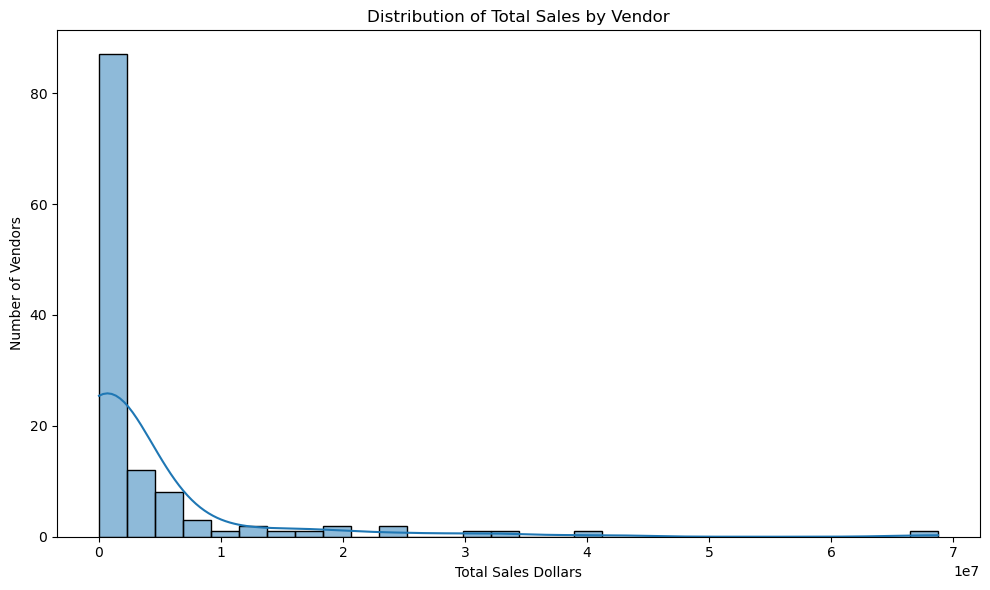

In [61]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="TotalSalesDollars",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Sales by Vendor")
plt.xlabel("Total Sales Dollars")
plt.ylabel("Number of Vendors")
plt.tight_layout()
plt.show()

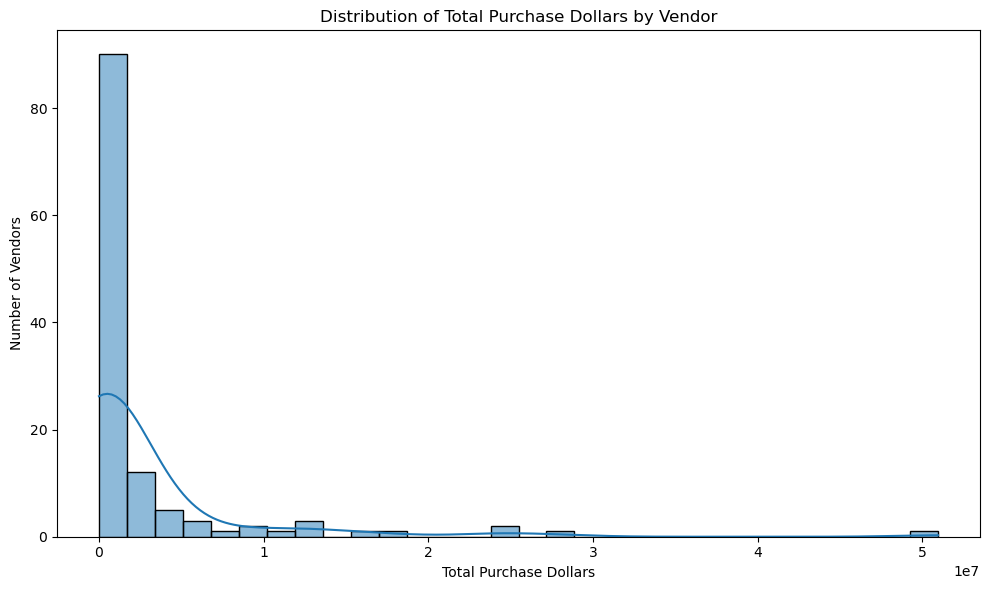

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="TotalPurchaseDollars",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Purchase Dollars by Vendor")
plt.xlabel("Total Purchase Dollars")
plt.ylabel("Number of Vendors")
plt.tight_layout()
plt.show()

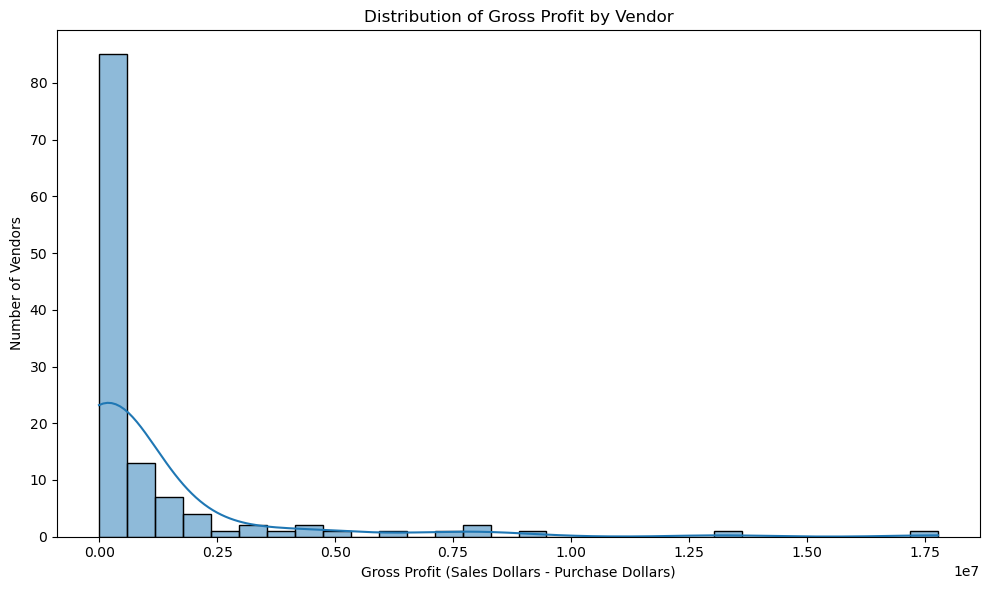

In [63]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="GrossProfit",
    bins=30,
    kde=True
)

plt.title("Distribution of Gross Profit by Vendor")
plt.xlabel("Gross Profit (Sales Dollars - Purchase Dollars)")
plt.ylabel("Number of Vendors")
plt.tight_layout()
plt.show()

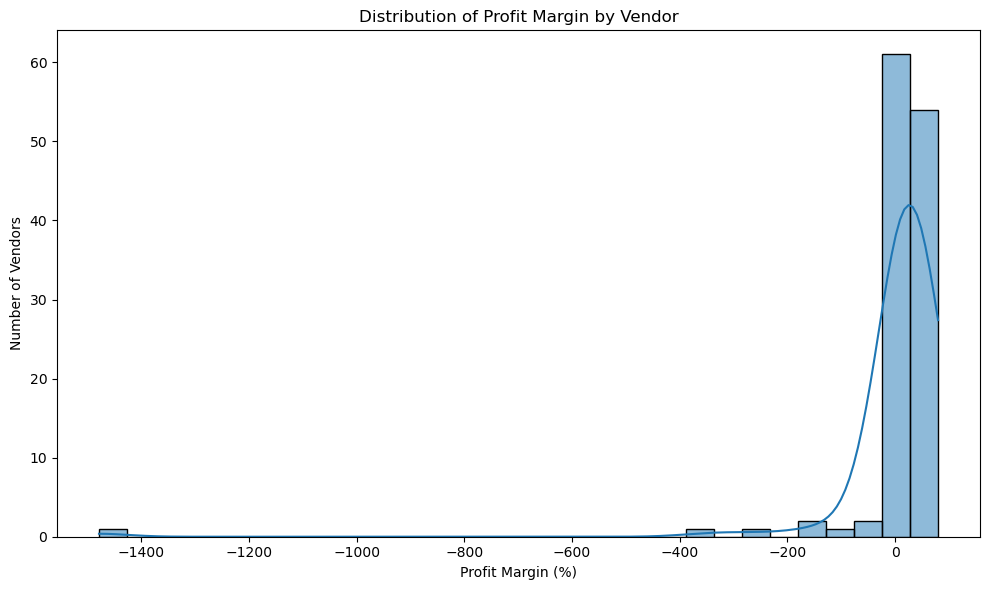

In [64]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="ProfitMarginPercentage",
    bins=30,
    kde=True
)

plt.title("Distribution of Profit Margin by Vendor")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Vendors")
plt.tight_layout()
plt.show()

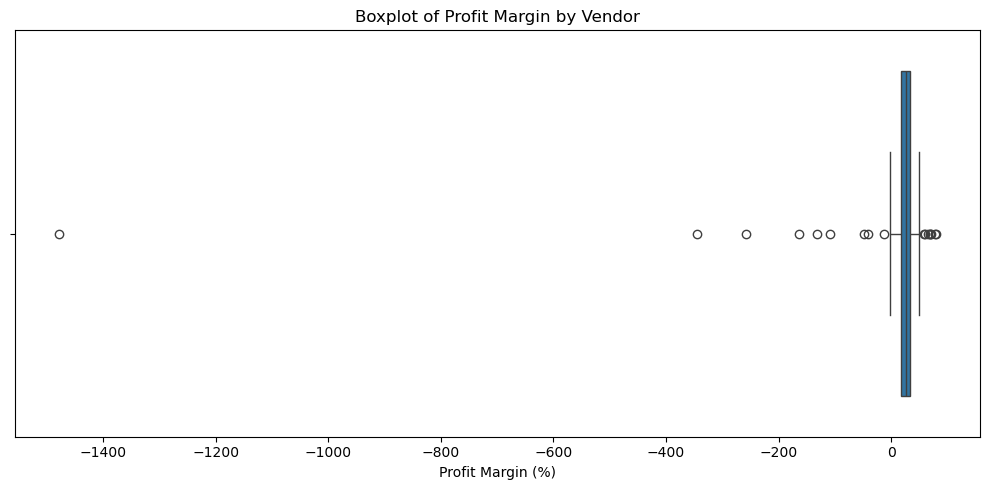

In [65]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=eda_df,
    x="ProfitMarginPercentage"
)

plt.title("Boxplot of Profit Margin by Vendor")
plt.xlabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

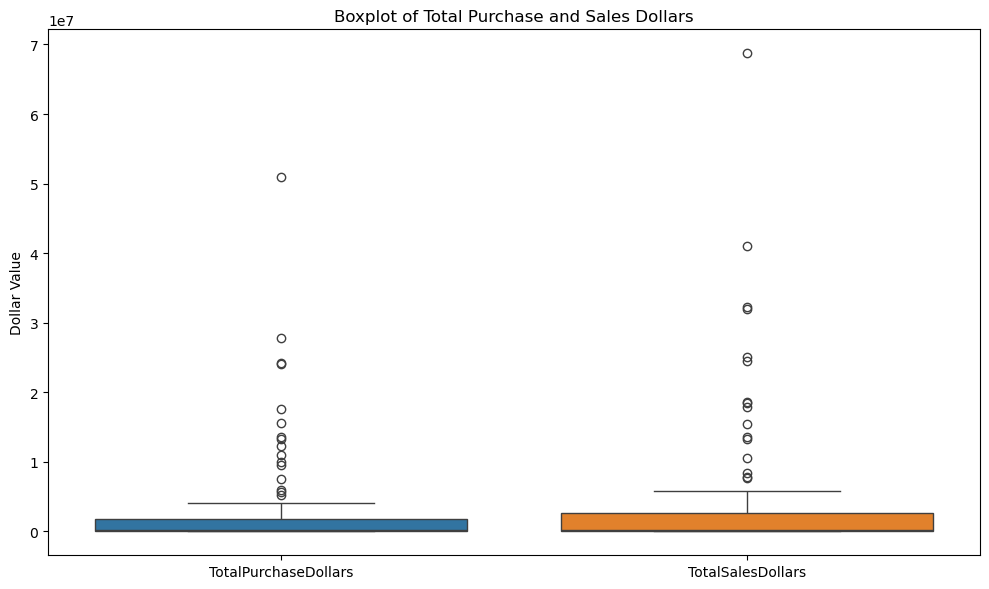

In [66]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=eda_df[
        ["TotalPurchaseDollars", "TotalSalesDollars"]
    ]
)

plt.title("Boxplot of Total Purchase and Sales Dollars")
plt.ylabel("Dollar Value")
plt.tight_layout()
plt.show()

In [67]:
def outlier_summary(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    return {
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    }


outlier_results = pd.DataFrame([
    outlier_summary(eda_df, "TotalPurchaseDollars"),
    outlier_summary(eda_df, "TotalSalesDollars"),
    outlier_summary(eda_df, "GrossProfit")
])

display(outlier_results)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,TotalPurchaseDollars,34829.855,1845489.585,1810659.730,-2.681160e+06,4.561479e+06,16
1,TotalSalesDollars,42081.360,2639174.790,2597093.430,-3.853559e+06,6.534815e+06,16
2,GrossProfit,5414.880,807920.655,802505.775,-1.198344e+06,2.011679e+06,16


In [68]:
correlation_columns = [
    "TotalPurchaseDollars",
    "TotalSalesDollars",
    "GrossProfit",
    "ProfitMarginPercentage",
    "TotalPurchaseQuantity",
    "TotalSalesQuantity",
    "AveragePurchasePrice",
    "AverageSalesPrice",
    "TotalFreight",
    "ProductCount",
    "UniqueBrandsSold"
]

correlation_matrix = eda_df[correlation_columns].corr()

display(correlation_matrix.round(2))

,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,ProfitMarginPercentage,TotalPurchaseQuantity,TotalSalesQuantity,AveragePurchasePrice,AverageSalesPrice,TotalFreight,ProductCount,UniqueBrandsSold
TotalPurchaseDollars,1.00,1.00,0.98,0.06,0.97,0.97,-0.01,-0.05,1.00,0.63,0.64
TotalSalesDollars,1.00,1.00,0.99,0.07,0.98,0.98,-0.02,-0.06,1.00,0.65,0.66
GrossProfit,0.98,0.99,1.00,0.07,0.97,0.97,-0.03,-0.07,0.98,0.70,0.70
ProfitMarginPercentage,0.06,0.07,0.07,1.00,0.07,0.07,0.04,0.01,0.06,0.08,0.08
TotalPurchaseQuantity,0.97,0.98,0.97,0.07,1.00,1.00,-0.06,-0.10,0.97,0.63,0.64
TotalSalesQuantity,0.97,0.98,0.97,0.07,1.00,1.00,-0.06,-0.10,0.97,0.63,0.63
AveragePurchasePrice,-0.01,-0.02,-0.03,0.04,-0.06,-0.06,1.00,0.98,-0.01,-0.09,-0.10
AverageSalesPrice,-0.05,-0.06,-0.07,0.01,-0.10,-0.10,0.98,1.00,-0.05,-0.10,-0.10
TotalFreight,1.00,1.00,0.98,0.06,0.97,0.97,-0.01,-0.05,1.00,0.64,0.64
ProductCount,0.63,0.65,0.70,0.08,0.63,0.63,-0.09,-0.10,0.64,1.00,1.00


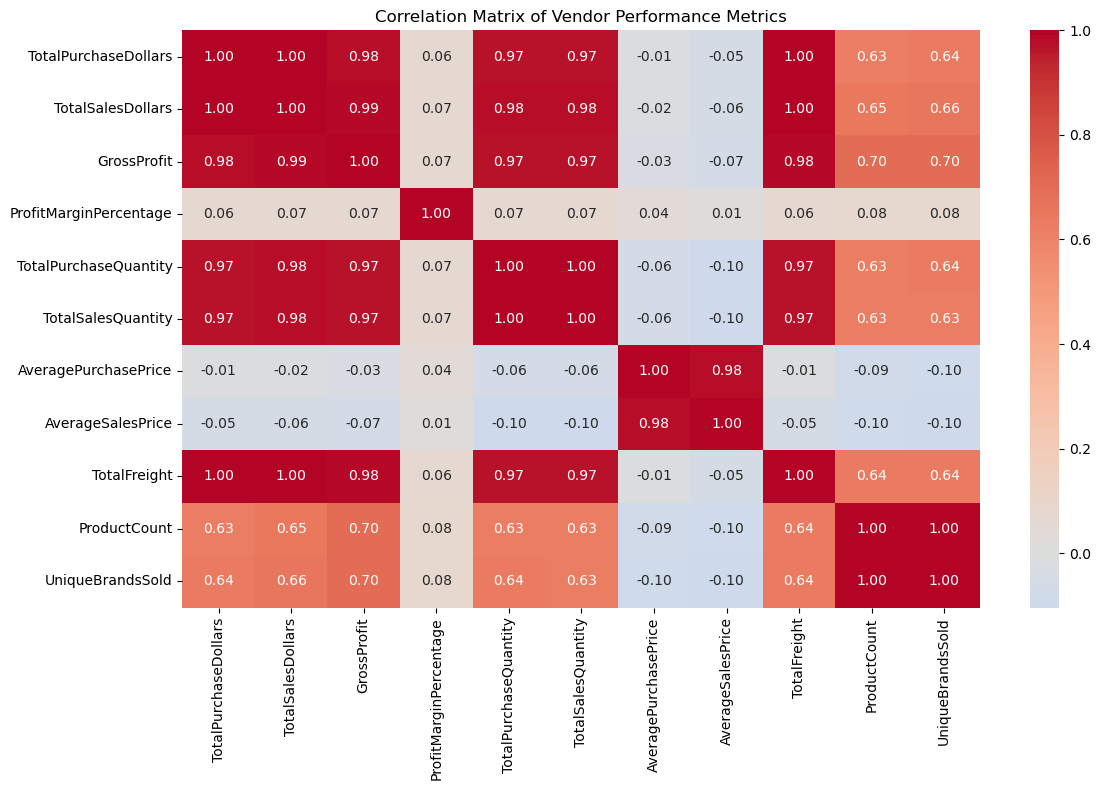

In [69]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Vendor Performance Metrics")
plt.tight_layout()
plt.show()

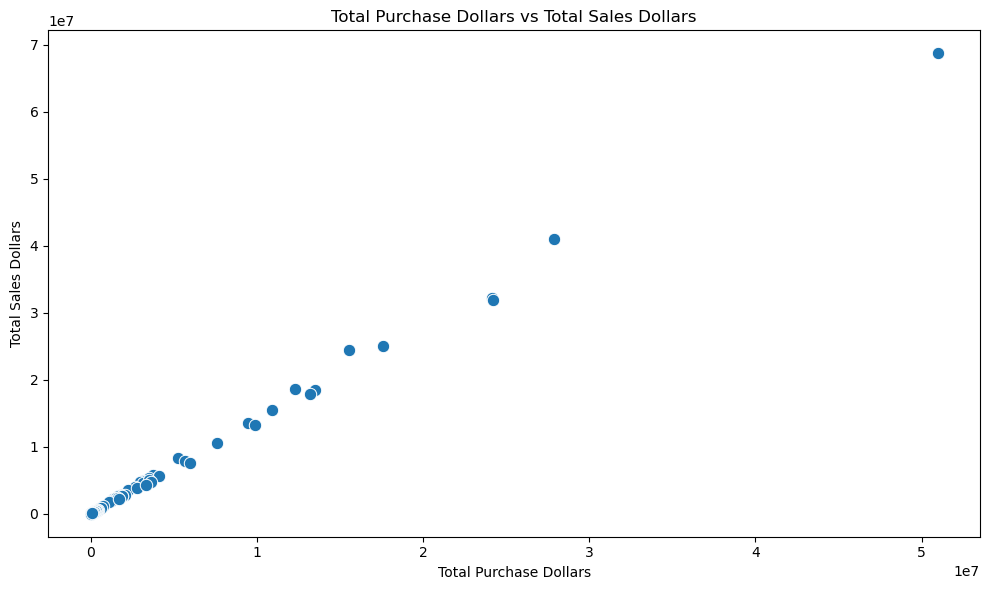

In [70]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="TotalPurchaseDollars",
    y="TotalSalesDollars",
    s=80
)

plt.title("Total Purchase Dollars vs Total Sales Dollars")
plt.xlabel("Total Purchase Dollars")
plt.ylabel("Total Sales Dollars")
plt.tight_layout()
plt.show()

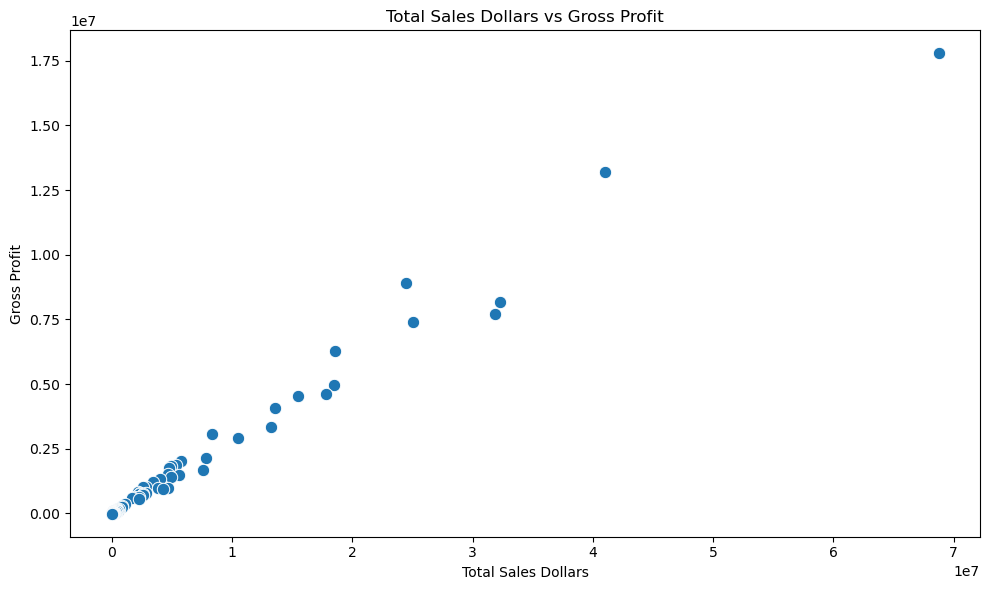

In [71]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="TotalSalesDollars",
    y="GrossProfit",
    s=80
)

plt.title("Total Sales Dollars vs Gross Profit")
plt.xlabel("Total Sales Dollars")
plt.ylabel("Gross Profit")
plt.tight_layout()
plt.show()

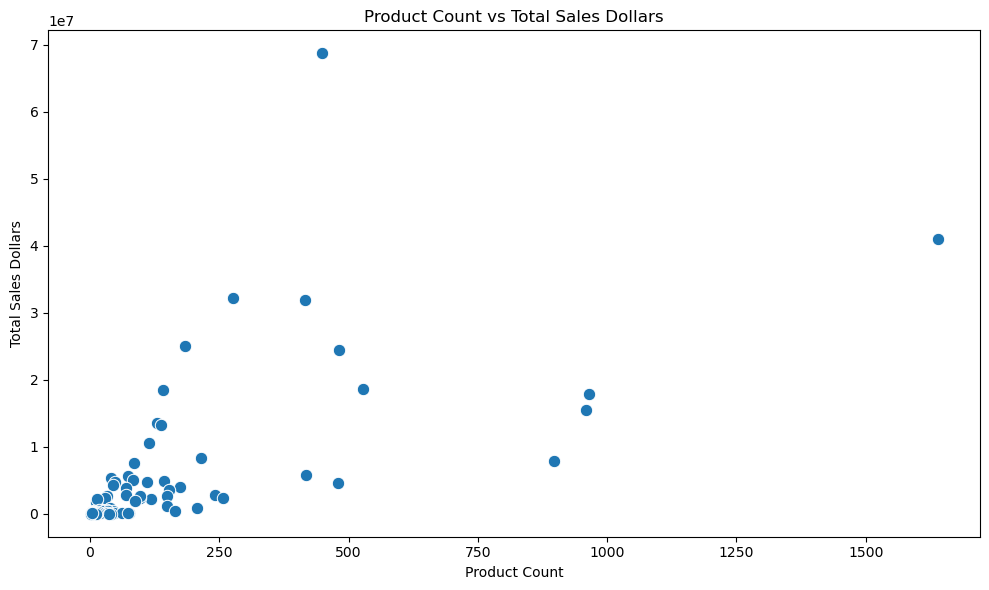

In [72]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="ProductCount",
    y="TotalSalesDollars",
    s=80
)

plt.title("Product Count vs Total Sales Dollars")
plt.xlabel("Product Count")
plt.ylabel("Total Sales Dollars")
plt.tight_layout()
plt.show()

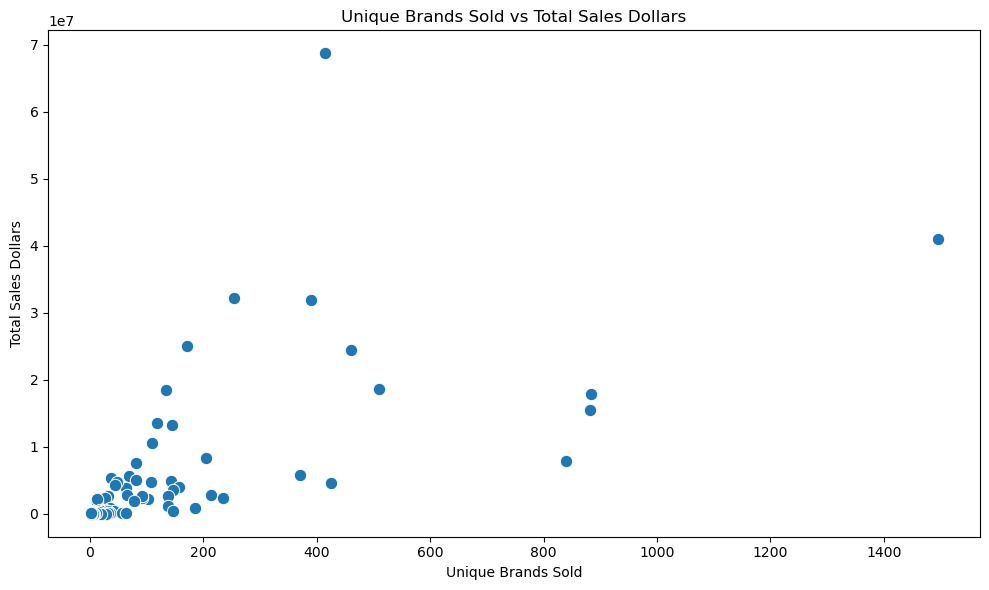

In [73]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="UniqueBrandsSold",
    y="TotalSalesDollars",
    s=80
)

plt.title("Unique Brands Sold vs Total Sales Dollars")
plt.xlabel("Unique Brands Sold")
plt.ylabel("Total Sales Dollars")
plt.tight_layout()
plt.show()

In [74]:
top_sales_vendors = (
    eda_df[
        ["VendorNumber", "VendorName", "TotalSalesDollars"]
    ]
    .sort_values("TotalSalesDollars", ascending=False)
    .head(10)
)

display(top_sales_vendors)

,VendorNumber,VendorName,TotalSalesDollars
0,3960,DIAGEO NORTH AMERICA INC,6.874242e+07
1,4425,MARTIGNETTI COMPANIES,4.104731e+07
3,17035,PERNOD RICARD USA,3.228125e+07
4,12546,JIM BEAM BRANDS COMPANY,3.190632e+07
5,480,BACARDI USA INC,2.501456e+07
2,1392,CONSTELLATION BRANDS INC,2.446917e+07
6,3252,E & J GALLO WINERY,1.855609e+07
7,1128,BROWN-FORMAN CORP,1.847856e+07
8,9165,ULTRA BEVERAGE COMPANY LLP,1.782294e+07
9,9552,M S WALKER INC,1.546525e+07


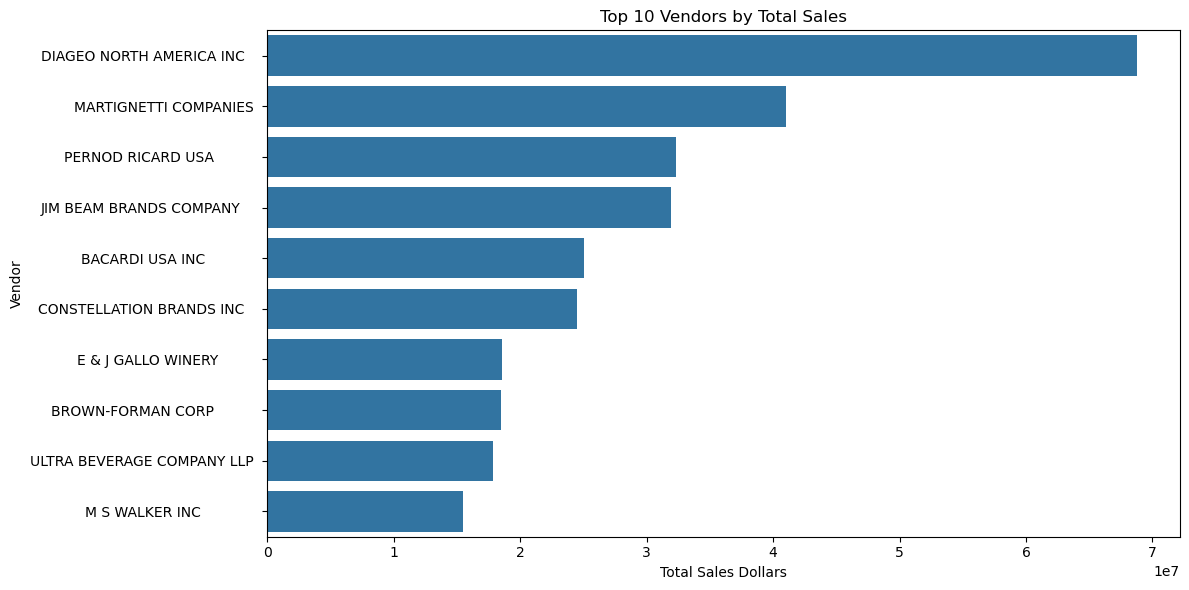

In [75]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_sales_vendors,
    x="TotalSalesDollars",
    y="VendorName"
)

plt.title("Top 10 Vendors by Total Sales")
plt.xlabel("Total Sales Dollars")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

In [76]:
top_profit_vendors = (
    eda_df[
        ["VendorNumber", "VendorName", "GrossProfit"]
    ]
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

display(top_profit_vendors)

,VendorNumber,VendorName,GrossProfit
0,3960,DIAGEO NORTH AMERICA INC,1.778262e+07
1,4425,MARTIGNETTI COMPANIES,1.318562e+07
2,1392,CONSTELLATION BRANDS INC,8.895255e+06
3,17035,PERNOD RICARD USA,8.157156e+06
4,12546,JIM BEAM BRANDS COMPANY,7.703169e+06
5,480,BACARDI USA INC,7.390178e+06
6,3252,E & J GALLO WINERY,6.266478e+06
7,1128,BROWN-FORMAN CORP,4.949124e+06
8,9165,ULTRA BEVERAGE COMPANY LLP,4.612325e+06
9,9552,M S WALKER INC,4.529430e+06


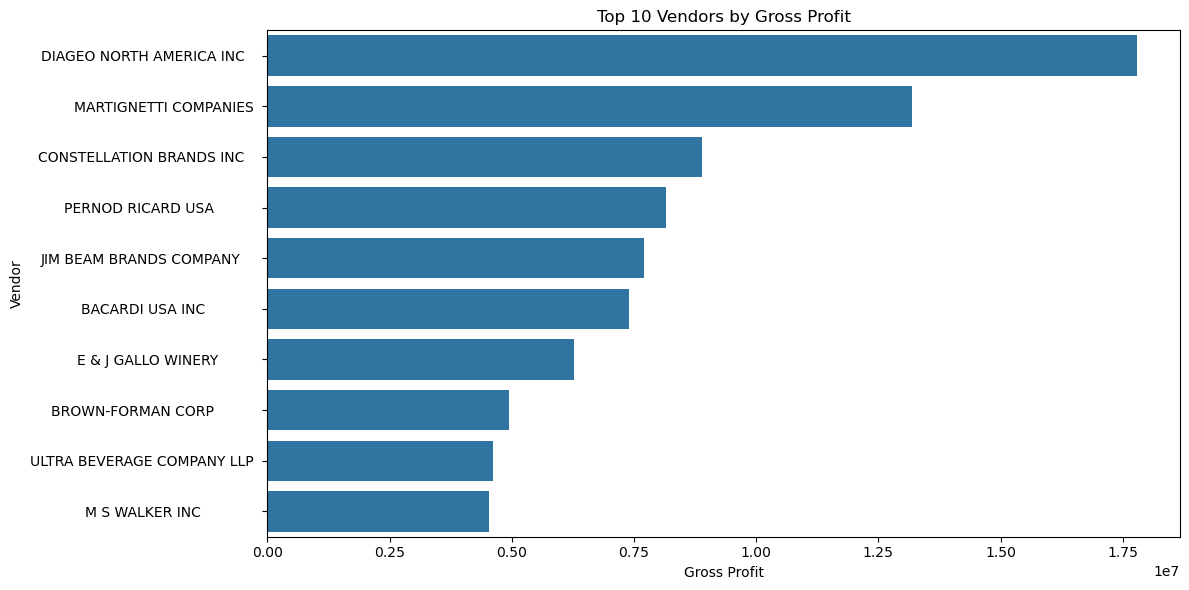

In [77]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_profit_vendors,
    x="GrossProfit",
    y="VendorName"
)

plt.title("Top 10 Vendors by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

In [78]:
top_sales_comparison = (
    eda_df[
        [
            "VendorName",
            "TotalSalesDollars",
            "GrossProfit",
            "ProfitMarginPercentage"
        ]
    ]
    .sort_values("TotalSalesDollars", ascending=False)
    .head(10)
)

display(top_sales_comparison)

,VendorName,TotalSalesDollars,GrossProfit,ProfitMarginPercentage
0,DIAGEO NORTH AMERICA INC,6.874242e+07,1.778262e+07,25.868483
1,MARTIGNETTI COMPANIES,4.104731e+07,1.318562e+07,32.122976
3,PERNOD RICARD USA,3.228125e+07,8.157156e+06,25.269024
4,JIM BEAM BRANDS COMPANY,3.190632e+07,7.703169e+06,24.143083
5,BACARDI USA INC,2.501456e+07,7.390178e+06,29.543510
2,CONSTELLATION BRANDS INC,2.446917e+07,8.895255e+06,36.352904
6,E & J GALLO WINERY,1.855609e+07,6.266478e+06,33.770471
7,BROWN-FORMAN CORP,1.847856e+07,4.949124e+06,26.783067
8,ULTRA BEVERAGE COMPANY LLP,1.782294e+07,4.612325e+06,25.878586
9,M S WALKER INC,1.546525e+07,4.529430e+06,29.287798


In [79]:
top_sales_comparison.sort_values(
    "TotalSalesDollars",
    ascending=False
).style.format({
    "TotalSalesDollars": "${:,.2f}",
    "GrossProfit": "${:,.2f}",
    "ProfitMarginPercentage": "{:.2f}%"
})

,VendorName,TotalSalesDollars,GrossProfit,ProfitMarginPercentage
0,DIAGEO NORTH AMERICA INC,"$68,742,416.99","$17,782,620.14",25.87%
1,MARTIGNETTI COMPANIES,"$41,047,306.30","$13,185,616.28",32.12%
3,PERNOD RICARD USA,"$32,281,247.95","$8,157,156.39",25.27%
4,JIM BEAM BRANDS COMPANY,"$31,906,320.54","$7,703,169.49",24.14%
5,BACARDI USA INC,"$25,014,556.89","$7,390,178.17",29.54%
2,CONSTELLATION BRANDS INC,"$24,469,172.93","$8,895,255.03",36.35%
6,E & J GALLO WINERY,"$18,556,085.61","$6,266,477.52",33.77%
7,BROWN-FORMAN CORP,"$18,478,557.47","$4,949,124.39",26.78%
8,ULTRA BEVERAGE COMPANY LLP,"$17,822,938.45","$4,612,324.52",25.88%
9,M S WALKER INC,"$15,465,247.75","$4,529,430.45",29.29%


In [80]:
negative_profit_vendors = (
    eda_df[
        eda_df["GrossProfit"] < 0
    ][
        [
            "VendorNumber",
            "VendorName",
            "TotalPurchaseDollars",
            "TotalSalesDollars",
            "GrossProfit",
            "ProfitMarginPercentage"
        ]
    ]
    .sort_values("GrossProfit")
)

display(negative_profit_vendors)

,VendorNumber,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,ProfitMarginPercentage
122,60,ADAMBA IMPORTS INTL INC,76770.25,67576.22,-9194.03,-13.605422
121,90059,BLACK COVE BEVERAGES,14465.06,6256.87,-8208.19,-131.186839
120,2,"IRA GOLDMAN AND WILLIAMS, LLP",5630.88,1265.58,-4365.30,-344.924857
119,3951,HIGHLAND WINE MERCHANTS LLC,5500.32,1533.68,-3966.64,-258.635439
118,6280,UNCORKED,2966.31,1124.38,-1841.93,-163.817393
117,3551,GILMANTON WINERY & VINEYARD,5393.04,3837.60,-1555.44,-40.531582
116,5083,LOYAL DOG WINERY,2320.80,1111.26,-1209.54,-108.844015
115,173357,TAMWORTH DISTILLING,41036.44,40021.12,-1015.32,-2.536960
114,287,APPOLO VINEYARDS LLC,2399.70,1616.92,-782.78,-48.411795
113,99166,STARK BREWING COMPANY,25961.04,25371.54,-589.50,-2.323470


In [81]:
print(
    "Number of vendors with negative GrossProfit:",
    len(negative_profit_vendors)
)

Number of vendors with negative GrossProfit: 11


In [82]:
top_freight_vendors = (
    eda_df[
        [
            "VendorNumber",
            "VendorName",
            "TotalFreight",
            "TotalPurchaseDollars",
            "FreightPercentage"
        ]
    ]
    .sort_values("TotalFreight", ascending=False)
    .head(10)
)

display(top_freight_vendors)

,VendorNumber,VendorName,TotalFreight,TotalPurchaseDollars,FreightPercentage
0,3960,DIAGEO NORTH AMERICA INC,257032.07,5.095980e+07,0.504382
1,4425,MARTIGNETTI COMPANIES,144929.24,2.786169e+07,0.520174
4,12546,JIM BEAM BRANDS COMPANY,123880.97,2.420315e+07,0.511838
3,17035,PERNOD RICARD USA,123780.22,2.412409e+07,0.513098
5,480,BACARDI USA INC,89286.27,1.762438e+07,0.506607
2,1392,CONSTELLATION BRANDS INC,79528.99,1.557392e+07,0.510655
7,1128,BROWN-FORMAN CORP,68601.68,1.352943e+07,0.507055
8,9165,ULTRA BEVERAGE COMPANY LLP,68054.70,1.321061e+07,0.515152
6,3252,E & J GALLO WINERY,61966.91,1.228961e+07,0.504222
9,9552,M S WALKER INC,55551.82,1.093582e+07,0.507981


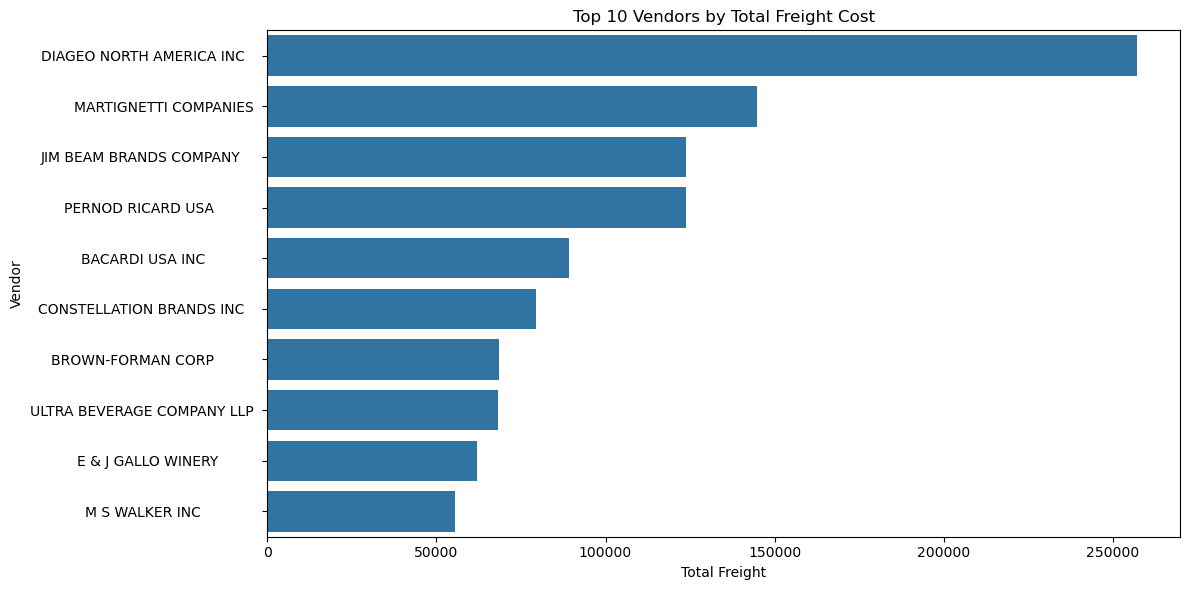

In [83]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_freight_vendors,
    x="TotalFreight",
    y="VendorName"
)

plt.title("Top 10 Vendors by Total Freight Cost")
plt.xlabel("Total Freight")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

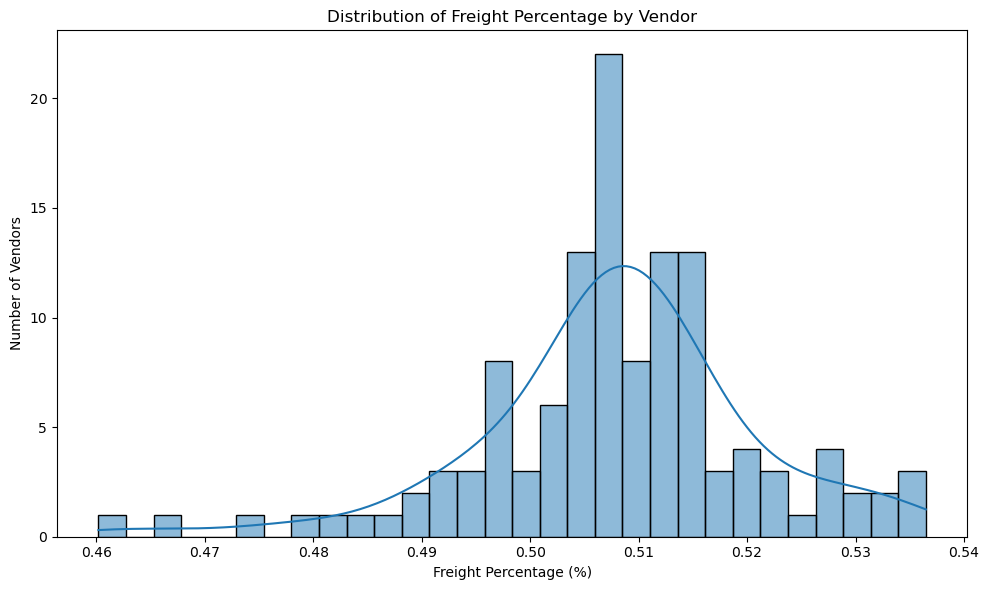

In [84]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="FreightPercentage",
    bins=30,
    kde=True
)

plt.title("Distribution of Freight Percentage by Vendor")
plt.xlabel("Freight Percentage (%)")
plt.ylabel("Number of Vendors")
plt.tight_layout()
plt.show()

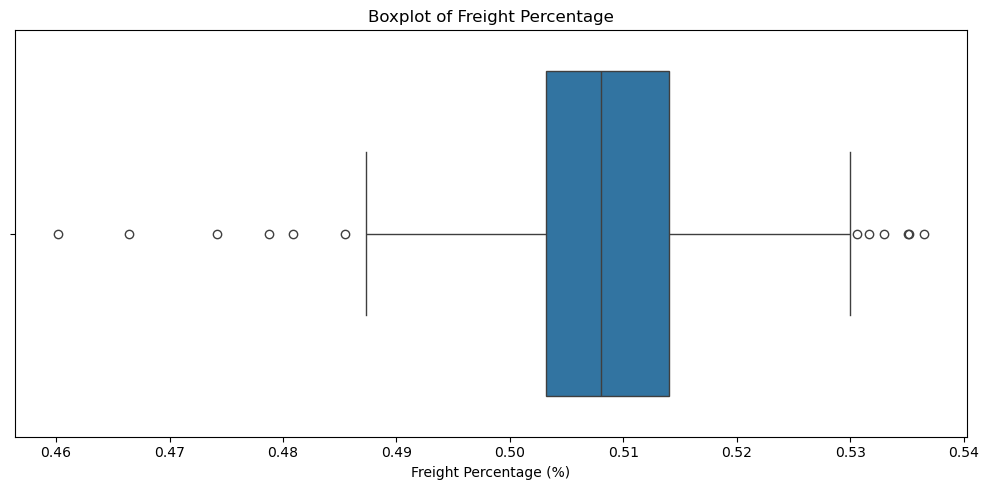

In [85]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=eda_df,
    x="FreightPercentage"
)

plt.title("Boxplot of Freight Percentage")
plt.xlabel("Freight Percentage (%)")
plt.tight_layout()
plt.show()

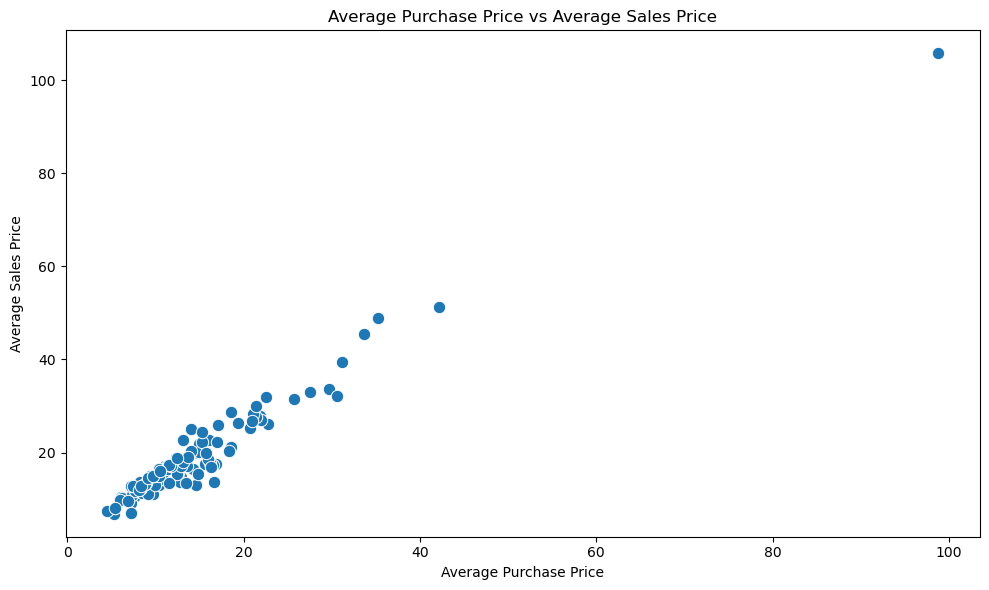

In [86]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="AveragePurchasePrice",
    y="AverageSalesPrice",
    s=80
)

plt.title("Average Purchase Price vs Average Sales Price")
plt.xlabel("Average Purchase Price")
plt.ylabel("Average Sales Price")
plt.tight_layout()
plt.show()

In [87]:
price_correlation = eda_df[
    ["AveragePurchasePrice", "AverageSalesPrice"]
].corr()

display(price_correlation.round(2))

,AveragePurchasePrice,AverageSalesPrice
AveragePurchasePrice,1.00,0.98
AverageSalesPrice,0.98,1.00


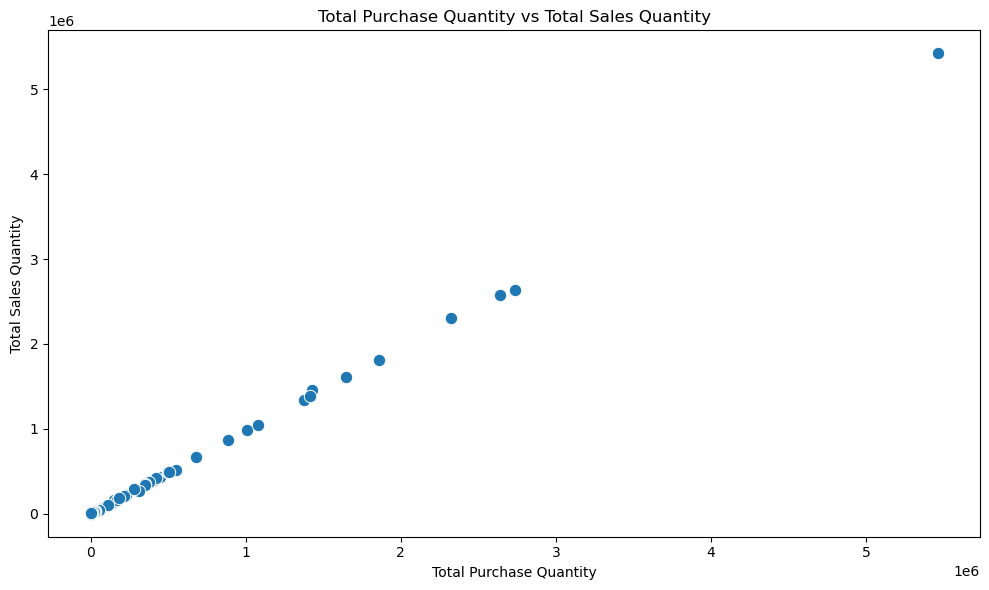

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="TotalPurchaseQuantity",
    y="TotalSalesQuantity",
    s=80
)

plt.title("Total Purchase Quantity vs Total Sales Quantity")
plt.xlabel("Total Purchase Quantity")
plt.ylabel("Total Sales Quantity")
plt.tight_layout()
plt.show()

In [89]:
quantity_correlation = eda_df[
    ["TotalPurchaseQuantity", "TotalSalesQuantity"]
].corr()

display(quantity_correlation.round(2))

,TotalPurchaseQuantity,TotalSalesQuantity
TotalPurchaseQuantity,1.0,1.0
TotalSalesQuantity,1.0,1.0


In [90]:
sales_concentration = (
    eda_df[
        ["VendorNumber", "VendorName", "TotalSalesDollars"]
    ]
    .sort_values("TotalSalesDollars", ascending=False)
    .reset_index(drop=True)
)

sales_concentration["CumulativeSales"] = (
    sales_concentration["TotalSalesDollars"].cumsum()
)

total_sales = sales_concentration["TotalSalesDollars"].sum()

sales_concentration["CumulativeSalesPercentage"] = (
    sales_concentration["CumulativeSales"] / total_sales * 100
)

display(
    sales_concentration.head(15)
)

,VendorNumber,VendorName,TotalSalesDollars,CumulativeSales,CumulativeSalesPercentage
0,3960,DIAGEO NORTH AMERICA INC,6.874242e+07,6.874242e+07,15.206435
1,4425,MARTIGNETTI COMPANIES,4.104731e+07,1.097897e+08,24.286464
2,17035,PERNOD RICARD USA,3.228125e+07,1.420710e+08,31.427364
3,12546,JIM BEAM BRANDS COMPANY,3.190632e+07,1.739773e+08,38.485326
4,480,BACARDI USA INC,2.501456e+07,1.989918e+08,44.018768
5,1392,CONSTELLATION BRANDS INC,2.446917e+07,2.234610e+08,49.431567
6,3252,E & J GALLO WINERY,1.855609e+07,2.420171e+08,53.536339
7,1128,BROWN-FORMAN CORP,1.847856e+07,2.604957e+08,57.623960
8,9165,ULTRA BEVERAGE COMPANY LLP,1.782294e+07,2.783186e+08,61.566553
9,9552,M S WALKER INC,1.546525e+07,2.937839e+08,64.987603


In [91]:
top_n = [5, 10, 20]

for n in top_n:
    contribution = (
        sales_concentration.head(n)["TotalSalesDollars"].sum()
        / total_sales
    ) * 100

    print(f"Top {n} vendors contribute {contribution:.2f}% of total sales")

Top 5 vendors contribute 44.02% of total sales
Top 10 vendors contribute 64.99% of total sales
Top 20 vendors contribute 83.31% of total sales


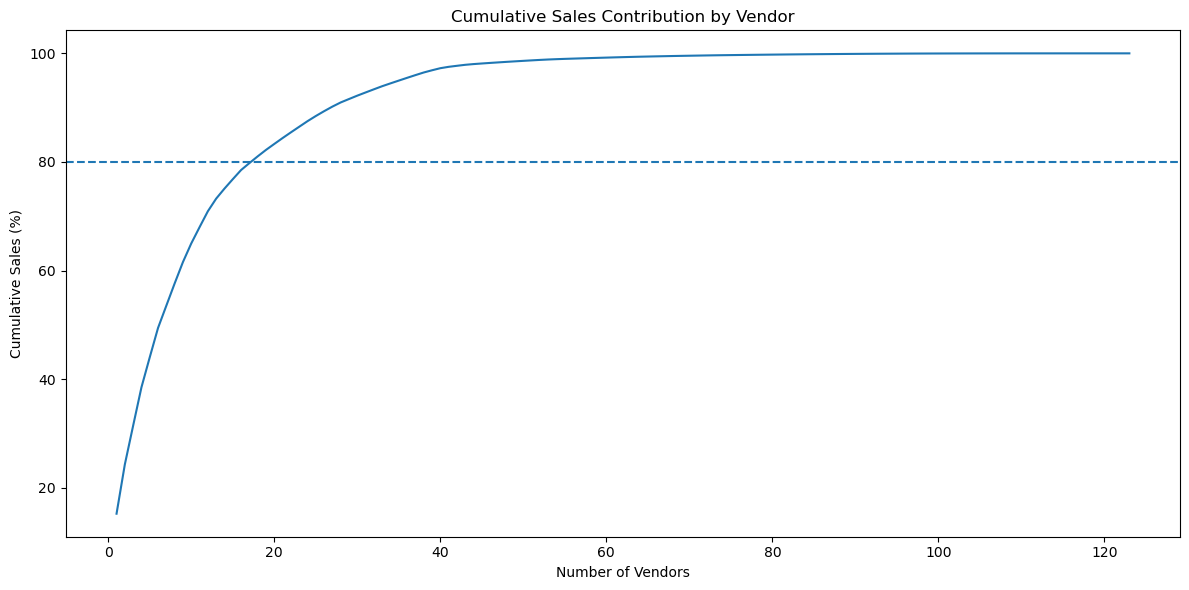

In [92]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(sales_concentration) + 1),
    sales_concentration["CumulativeSalesPercentage"]
)

plt.axhline(
    80,
    linestyle="--"
)

plt.title("Cumulative Sales Contribution by Vendor")
plt.xlabel("Number of Vendors")
plt.ylabel("Cumulative Sales (%)")
plt.tight_layout()
plt.show()

In [93]:
def performance_segment(row):
    if row["GrossProfit"] < 0:
        return "Negative Profit"

    elif (
        row["TotalSalesDollars"] >= eda_df["TotalSalesDollars"].median()
        and row["ProfitMarginPercentage"] >= eda_df["ProfitMarginPercentage"].median()
    ):
        return "High Sales & High Margin"

    elif (
        row["TotalSalesDollars"] >= eda_df["TotalSalesDollars"].median()
        and row["ProfitMarginPercentage"] < eda_df["ProfitMarginPercentage"].median()
    ):
        return "High Sales & Lower Margin"

    elif (
        row["TotalSalesDollars"] < eda_df["TotalSalesDollars"].median()
        and row["ProfitMarginPercentage"] >= eda_df["ProfitMarginPercentage"].median()
    ):
        return "Lower Sales & High Margin"

    else:
        return "Lower Sales & Lower Margin"


eda_df["PerformanceSegment"] = eda_df.apply(
    performance_segment,
    axis=1
)

display(
    eda_df[
        [
            "VendorNumber",
            "VendorName",
            "TotalSalesDollars",
            "GrossProfit",
            "ProfitMarginPercentage",
            "PerformanceSegment"
        ]
    ].head(20)
)

,VendorNumber,VendorName,TotalSalesDollars,GrossProfit,ProfitMarginPercentage,PerformanceSegment
0,3960,DIAGEO NORTH AMERICA INC,6.874242e+07,1.778262e+07,25.868483,High Sales & Lower Margin
1,4425,MARTIGNETTI COMPANIES,4.104731e+07,1.318562e+07,32.122976,High Sales & High Margin
2,1392,CONSTELLATION BRANDS INC,2.446917e+07,8.895255e+06,36.352904,High Sales & High Margin
3,17035,PERNOD RICARD USA,3.228125e+07,8.157156e+06,25.269024,High Sales & Lower Margin
4,12546,JIM BEAM BRANDS COMPANY,3.190632e+07,7.703169e+06,24.143083,High Sales & Lower Margin
5,480,BACARDI USA INC,2.501456e+07,7.390178e+06,29.543510,High Sales & High Margin
6,3252,E & J GALLO WINERY,1.855609e+07,6.266478e+06,33.770471,High Sales & High Margin
7,1128,BROWN-FORMAN CORP,1.847856e+07,4.949124e+06,26.783067,High Sales & Lower Margin
8,9165,ULTRA BEVERAGE COMPANY LLP,1.782294e+07,4.612325e+06,25.878586,High Sales & Lower Margin
9,9552,M S WALKER INC,1.546525e+07,4.529430e+06,29.287798,High Sales & High Margin


In [94]:
segment_counts = (
    eda_df["PerformanceSegment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["PerformanceSegment", "VendorCount"]

display(segment_counts)

,PerformanceSegment,VendorCount
0,High Sales & High Margin,35
1,High Sales & Lower Margin,27
2,Lower Sales & High Margin,27
3,Lower Sales & Lower Margin,23
4,Negative Profit,11


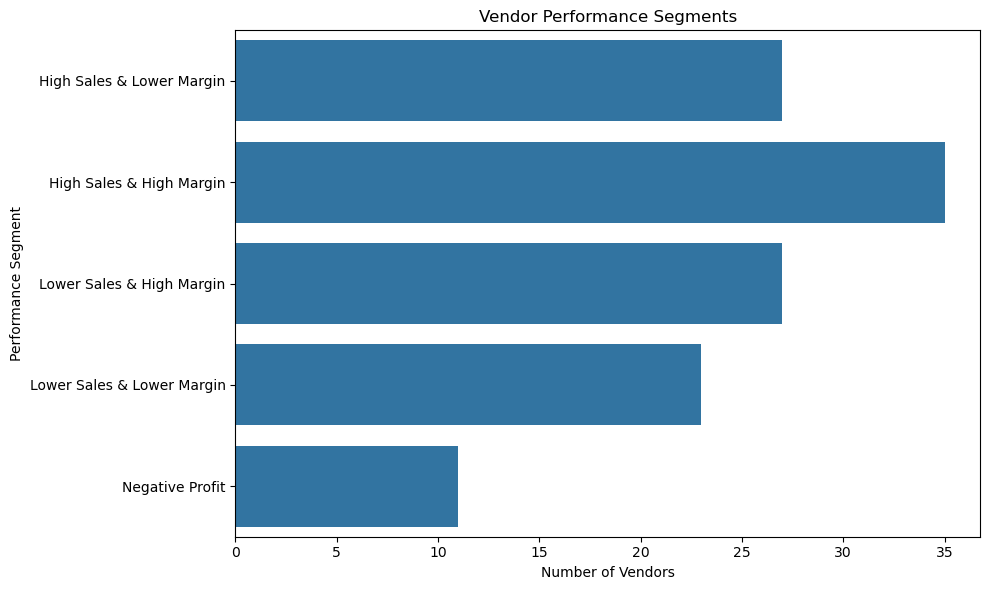

In [95]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=eda_df,
    y="PerformanceSegment"
)

plt.title("Vendor Performance Segments")
plt.xlabel("Number of Vendors")
plt.ylabel("Performance Segment")
plt.tight_layout()
plt.show()

In [96]:
from scipy.stats import pearsonr

purchase_sales_corr, p_value = pearsonr(
    eda_df["TotalPurchaseDollars"],
    eda_df["TotalSalesDollars"]
)

print(f"Pearson Correlation: {purchase_sales_corr:.4f}")
print(f"P-value: {p_value:.10f}")

Pearson Correlation: 0.9986
P-value: 0.0000000000


In [97]:
from scipy.stats import pearsonr

sales_product_corr, sales_product_p = pearsonr(
    eda_df["ProductCount"],
    eda_df["TotalSalesDollars"]
)

print(f"Pearson Correlation: {sales_product_corr:.4f}")
print(f"P-value: {sales_product_p:.10f}")

Pearson Correlation: 0.6514
P-value: 0.0000000000


In [98]:
from scipy.stats import pearsonr

sales_margin_corr, sales_margin_p = pearsonr(
    eda_df["TotalSalesDollars"],
    eda_df["ProfitMarginPercentage"]
)

print(f"Pearson Correlation: {sales_margin_corr:.4f}")
print(f"P-value: {sales_margin_p:.10f}")

Pearson Correlation: 0.0668
P-value: 0.4629415382


In [99]:
from scipy.stats import pearsonr

sales_brand_corr, sales_brand_p = pearsonr(
    eda_df["UniqueBrandsSold"],
    eda_df["TotalSalesDollars"]
)

print(f"Pearson Correlation: {sales_brand_corr:.4f}")
print(f"P-value: {sales_brand_p:.10f}")

Pearson Correlation: 0.6563
P-value: 0.0000000000


In [100]:
from scipy.stats import pearsonr

price_corr, price_p = pearsonr(
    eda_df["AveragePurchasePrice"],
    eda_df["AverageSalesPrice"]
)

print(f"Pearson Correlation: {price_corr:.4f}")
print(f"P-value: {price_p:.10f}")

Pearson Correlation: 0.9767
P-value: 0.0000000000


In [101]:
from scipy.stats import pearsonr

quantity_corr, quantity_p = pearsonr(
    eda_df["TotalPurchaseQuantity"],
    eda_df["TotalSalesQuantity"]
)

print(f"Pearson Correlation: {quantity_corr:.4f}")
print(f"P-value: {quantity_p:.10f}")

Pearson Correlation: 0.9999
P-value: 0.0000000000


In [102]:
from scipy.stats import pearsonr

freight_purchase_corr, freight_purchase_p = pearsonr(
    eda_df["TotalPurchaseDollars"],
    eda_df["TotalFreight"]
)

print(f"Pearson Correlation: {freight_purchase_corr:.4f}")
print(f"P-value: {freight_purchase_p:.10f}")

Pearson Correlation: 0.9999
P-value: 0.0000000000


In [103]:
statistical_results = pd.DataFrame({
    "Relationship": [
        "Purchase Dollars vs Sales Dollars",
        "Product Count vs Sales Dollars",
        "Sales Dollars vs Profit Margin",
        "Unique Brands vs Sales Dollars",
        "Average Purchase Price vs Average Sales Price",
        "Purchase Quantity vs Sales Quantity",
        "Purchase Dollars vs Freight"
    ],
    "Correlation": [
        purchase_sales_corr,
        sales_product_corr,
        sales_margin_corr,
        sales_brand_corr,
        price_corr,
        quantity_corr,
        freight_purchase_corr
    ],
    "P_Value": [
        p_value,
        sales_product_p,
        sales_margin_p,
        sales_brand_p,
        price_p,
        quantity_p,
        freight_purchase_p
    ]
})

statistical_results["Significant_at_5pct"] = (
    statistical_results["P_Value"] < 0.05
)

display(
    statistical_results.style.format({
        "Correlation": "{:.4f}",
        "P_Value": "{:.10f}"
    })
)

,Relationship,Correlation,P_Value,Significant_at_5pct
0,Purchase Dollars vs Sales Dollars,0.9986,0.0000000000,True
1,Product Count vs Sales Dollars,0.6514,0.0000000000,True
2,Sales Dollars vs Profit Margin,0.0668,0.4629415382,False
3,Unique Brands vs Sales Dollars,0.6563,0.0000000000,True
4,Average Purchase Price vs Average Sales Price,0.9767,0.0000000000,True
5,Purchase Quantity vs Sales Quantity,0.9999,0.0000000000,True
6,Purchase Dollars vs Freight,0.9999,0.0000000000,True


In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = eda_df[["ProductCount"]]
y = eda_df["TotalSalesDollars"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Coefficient: {model.coef_[0]:,.2f}")
print(f"Intercept: {model.intercept_:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:,.2f}")

Coefficient: 26,794.35
Intercept: 1,006,317.32
R² Score: 0.4243
RMSE: 6,936,428.97


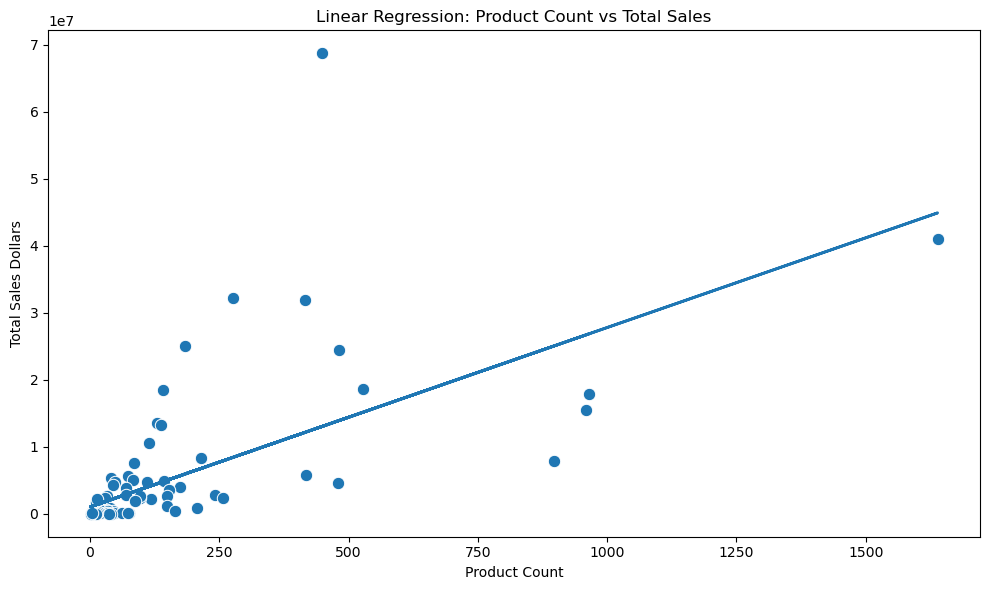

In [105]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="ProductCount",
    y="TotalSalesDollars",
    s=80
)

plt.plot(
    eda_df["ProductCount"],
    y_pred,
    linewidth=2
)

plt.title("Linear Regression: Product Count vs Total Sales")
plt.xlabel("Product Count")
plt.ylabel("Total Sales Dollars")
plt.tight_layout()
plt.show()

In [106]:
# Calculate residuals
residuals = y - y_pred

regression_results = pd.DataFrame({
    "VendorNumber": eda_df["VendorNumber"],
    "VendorName": eda_df["VendorName"],
    "ActualSales": y,
    "PredictedSales": y_pred,
    "Residual": residuals
})

display(
    regression_results
    .sort_values("Residual", ascending=False)
    .head(10)
)

,VendorNumber,VendorName,ActualSales,PredictedSales,Residual
0,3960,DIAGEO NORTH AMERICA INC,6.874242e+07,1.303698e+07,5.570544e+07
3,17035,PERNOD RICARD USA,3.228125e+07,8.428352e+06,2.385290e+07
4,12546,JIM BEAM BRANDS COMPANY,3.190632e+07,1.212597e+07,1.978035e+07
5,480,BACARDI USA INC,2.501456e+07,5.936477e+06,1.907808e+07
7,1128,BROWN-FORMAN CORP,1.847856e+07,4.811115e+06,1.366744e+07
2,1392,CONSTELLATION BRANDS INC,2.446917e+07,1.389440e+07,1.057477e+07
10,8112,MOET HENNESSY USA INC,1.354693e+07,4.462788e+06,9.084143e+06
11,8004,SAZERAC CO INC,1.325093e+07,4.703937e+06,8.546991e+06
13,7245,PROXIMO SPIRITS INC.,1.051625e+07,4.060873e+06,6.455374e+06
19,3664,WILLIAM GRANT & SONS INC,7.635828e+06,3.283837e+06,4.351991e+06


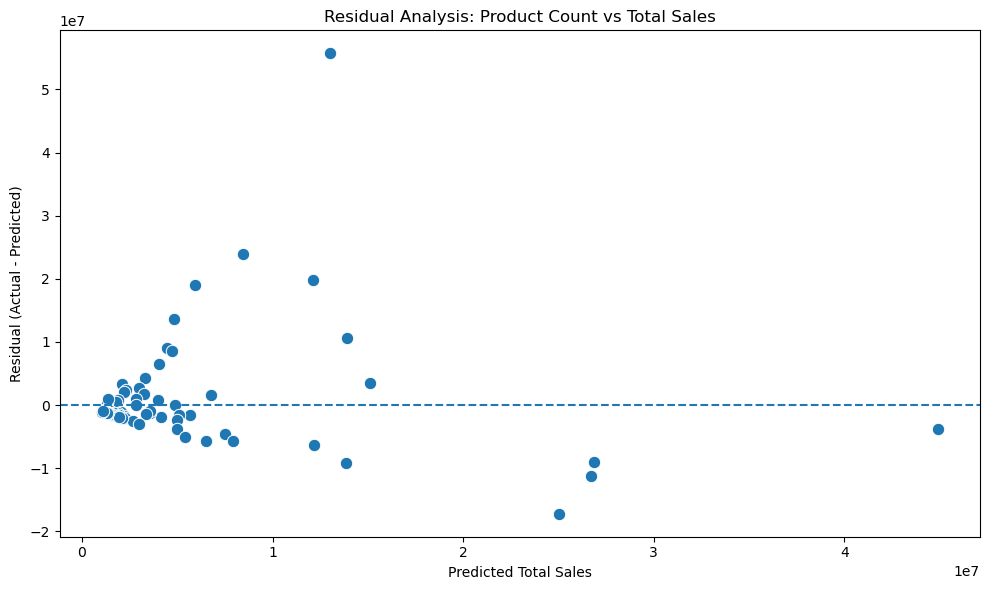

In [107]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    s=80
)

plt.axhline(0, linestyle="--")

plt.title("Residual Analysis: Product Count vs Total Sales")
plt.xlabel("Predicted Total Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

In [108]:
phase3_summary = pd.DataFrame({
    "Metric": [
        "Total Vendors",
        "Negative Profit Vendors",
        "Top Vendor Sales",
        "Average Vendor Sales",
        "Average Vendor Gross Profit",
        "Average Profit Margin",
        "Purchase-Sales Correlation",
        "Product Count-Sales Correlation",
        "Sales-Margin Correlation",
        "Purchase Price-Sales Price Correlation",
        "Purchase Quantity-Sales Quantity Correlation",
        "Purchase-Freight Correlation",
        "Product Count Regression R²"
    ],
    "Value": [
        len(eda_df),
        len(negative_profit_vendors),
        eda_df["TotalSalesDollars"].max(),
        eda_df["TotalSalesDollars"].mean(),
        eda_df["GrossProfit"].mean(),
        eda_df["ProfitMarginPercentage"].mean(),
        purchase_sales_corr,
        sales_product_corr,
        sales_margin_corr,
        price_corr,
        quantity_corr,
        freight_purchase_corr,
        r2
    ]
})

display(
    phase3_summary.style.format({
        "Value": "{:,.4f}"
    })
)

,Metric,Value
0,Total Vendors,123.0000
1,Negative Profit Vendors,11.0000
2,Top Vendor Sales,"68,742,416.9900"
3,Average Vendor Sales,"3,675,295.7127"
4,Average Vendor Gross Profit,"1,058,218.4564"
5,Average Profit Margin,4.8938
6,Purchase-Sales Correlation,0.9986
7,Product Count-Sales Correlation,0.6514
8,Sales-Margin Correlation,0.0668
9,Purchase Price-Sales Price Correlation,0.9767


In [109]:
inventory_query = """
SELECT
    COUNT(*) AS TotalInventoryRecords,
    COUNT(DISTINCT InventoryId) AS UniqueInventoryItems,
    SUM(onHand) AS TotalUnitsOnHand,
    SUM(onHand * Price) AS InventoryValue
FROM begin_inventory;
"""

begin_inventory_summary = pd.read_sql(inventory_query, engine)

display(begin_inventory_summary)

,TotalInventoryRecords,UniqueInventoryItems,TotalUnitsOnHand,InventoryValue
0,206529,206529,4219275,6.805378e+07


In [110]:
inventory_query = """
SELECT
    COUNT(*) AS TotalInventoryRecords,
    COUNT(DISTINCT InventoryId) AS UniqueInventoryItems,
    SUM(onHand) AS TotalUnitsOnHand,
    SUM(onHand * Price) AS InventoryValue
FROM end_inventory;
"""

end_inventory_summary = pd.read_sql(inventory_query, engine)

display(end_inventory_summary)

,TotalInventoryRecords,UniqueInventoryItems,TotalUnitsOnHand,InventoryValue
0,224489,224489,4885776,7.970485e+07


In [111]:
# Extract values from the two summary tables

begin_units = begin_inventory_summary.loc[0, "TotalUnitsOnHand"]
end_units = end_inventory_summary.loc[0, "TotalUnitsOnHand"]

begin_value = begin_inventory_summary.loc[0, "InventoryValue"]
end_value = end_inventory_summary.loc[0, "InventoryValue"]

# Calculate changes

unit_change = end_units - begin_units
value_change = end_value - begin_value

unit_change_pct = (unit_change / begin_units) * 100
value_change_pct = (value_change / begin_value) * 100

inventory_movement = pd.DataFrame({
    "Metric": [
        "Beginning Inventory Units",
        "Ending Inventory Units",
        "Change in Units",
        "Unit Change (%)",
        "Beginning Inventory Value",
        "Ending Inventory Value",
        "Change in Inventory Value",
        "Value Change (%)"
    ],
    "Value": [
        begin_units,
        end_units,
        unit_change,
        unit_change_pct,
        begin_value,
        end_value,
        value_change,
        value_change_pct
    ]
})

display(
    inventory_movement.style.format({
        "Value": "{:,.2f}"
    })
)

,Metric,Value
0,Beginning Inventory Units,"4,219,275.00"
1,Ending Inventory Units,"4,885,776.00"
2,Change in Units,"666,501.00"
3,Unit Change (%),15.80
4,Beginning Inventory Value,"68,053,780.17"
5,Ending Inventory Value,"79,704,851.13"
6,Change in Inventory Value,"11,651,070.96"
7,Value Change (%),17.12


In [112]:
store_inventory_query = """
WITH BeginStore AS (
    SELECT
        Store,
        SUM(onHand) AS BeginUnits,
        SUM(onHand * Price) AS BeginInventoryValue
    FROM begin_inventory
    GROUP BY Store
),

EndStore AS (
    SELECT
        Store,
        SUM(onHand) AS EndUnits,
        SUM(onHand * Price) AS EndInventoryValue
    FROM end_inventory
    GROUP BY Store
),

StoreCity AS (
    SELECT
        Store,
        MAX(City) AS City
    FROM begin_inventory
    WHERE City IS NOT NULL
    GROUP BY Store
)

SELECT
    b.Store,
    c.City,
    b.BeginUnits,
    e.EndUnits,
    e.EndUnits - b.BeginUnits AS UnitChange,
    b.BeginInventoryValue,
    e.EndInventoryValue,
    e.EndInventoryValue - b.BeginInventoryValue AS ValueChange
FROM BeginStore b
INNER JOIN EndStore e
    ON b.Store = e.Store
LEFT JOIN StoreCity c
    ON b.Store = c.Store
ORDER BY ValueChange DESC;
"""

store_inventory_change = pd.read_sql(
    store_inventory_query,
    engine
)

display(store_inventory_change.head(15))

,Store,City,BeginUnits,EndUnits,UnitChange,BeginInventoryValue,EndInventoryValue,ValueChange
0,50,MOUNTMEND,94720,260717,165997,1649808.22,4887260.68,3237452.46
1,74,PAENTMARWY,55464,166015,110551,758303.37,2803645.13,2045341.76
2,41,LARNWICK,52440,112885,60445,776215.81,1991001.75,1214785.94
3,44,PORTHCRAWL,41930,87225,45295,611206.15,1405905.73,794699.58
4,19,WINTERVALE,22476,52138,29662,300694.44,843990.56,543296.12
5,15,WANBORNE,65093,95827,30734,1098734.84,1614792.15,516057.31
6,1,HARDERSFIELD,49917,79827,29910,838079.59,1206845.93,368766.34
7,78,EASTHAVEN,21395,39746,18351,264342.71,561110.97,296768.26
8,55,DRY GULCH,119641,125584,5943,2001263.66,2234836.35,233572.69
9,38,GOULCREST,114368,129397,15029,2232698.77,2463906.85,231208.08


In [113]:
top_store_inventory_change = (
    store_inventory_change
    .assign(
        AbsoluteValueChange=lambda x: x["ValueChange"].abs()
    )
    .sort_values(
        "AbsoluteValueChange",
        ascending=False
    )
    .head(15)
)

display(
    top_store_inventory_change[
        [
            "Store",
            "City",
            "BeginInventoryValue",
            "EndInventoryValue",
            "ValueChange"
        ]
    ]
)

,Store,City,BeginInventoryValue,EndInventoryValue,ValueChange
0,50,MOUNTMEND,1649808.22,4887260.68,3237452.46
1,74,PAENTMARWY,758303.37,2803645.13,2045341.76
2,41,LARNWICK,776215.81,1991001.75,1214785.94
3,44,PORTHCRAWL,611206.15,1405905.73,794699.58
4,19,WINTERVALE,300694.44,843990.56,543296.12
5,15,WANBORNE,1098734.84,1614792.15,516057.31
6,1,HARDERSFIELD,838079.59,1206845.93,368766.34
78,46,TYWARDREATH,342989.13,0.00,-342989.13
7,78,EASTHAVEN,264342.71,561110.97,296768.26
8,55,DRY GULCH,2001263.66,2234836.35,233572.69


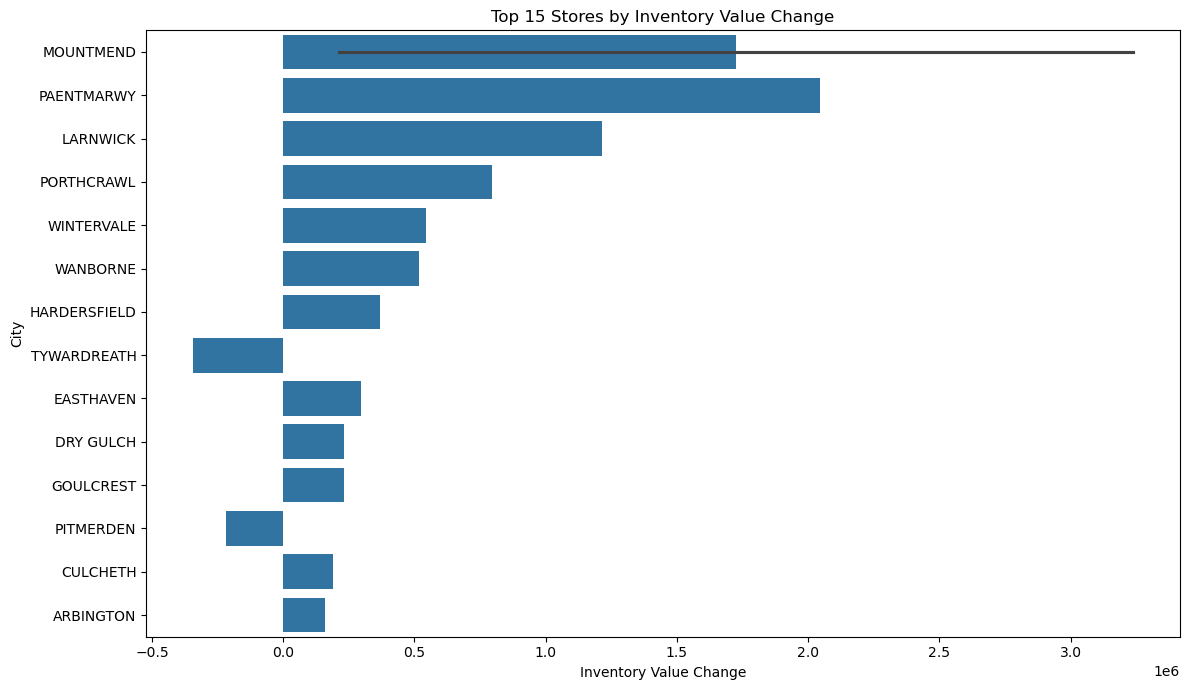

In [114]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_store_inventory_change,
    x="ValueChange",
    y="City"
)

plt.title("Top 15 Stores by Inventory Value Change")
plt.xlabel("Inventory Value Change")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [115]:
brand_inventory_query = """
WITH BeginBrand AS (
    SELECT
        Brand,
        MAX(Description) AS Description,
        SUM(onHand) AS BeginUnits,
        SUM(onHand * Price) AS BeginInventoryValue
    FROM begin_inventory
    GROUP BY Brand
),

EndBrand AS (
    SELECT
        Brand,
        SUM(onHand) AS EndUnits,
        SUM(onHand * Price) AS EndInventoryValue
    FROM end_inventory
    GROUP BY Brand
)

SELECT
    b.Brand,
    b.Description,
    b.BeginUnits,
    e.EndUnits,
    e.EndUnits - b.BeginUnits AS UnitChange,
    b.BeginInventoryValue,
    e.EndInventoryValue,
    e.EndInventoryValue - b.BeginInventoryValue AS ValueChange
FROM BeginBrand b
INNER JOIN EndBrand e
    ON b.Brand = e.Brand
ORDER BY ValueChange DESC;
"""

brand_inventory_change = pd.read_sql(
    brand_inventory_query,
    engine
)

display(brand_inventory_change.head(15))

,Brand,Description,BeginUnits,EndUnits,UnitChange,BeginInventoryValue,EndInventoryValue,ValueChange
0,3102,Smirnoff Traveler,1087,14208,13121,19555.13,241393.92,221838.79
1,2753,Johnnie Walker Black Label,4625,7849,3224,286703.75,470861.51,184157.76
2,2757,Johnnie Walker Red Label,6094,11603,5509,182759.06,336370.97,153611.91
3,1346,Knob Creek Bourbon,2298,5694,3396,68917.02,176457.06,107540.04
4,3405,Tito's Handmade Vodka,8477,12268,3791,254225.23,355649.32,101424.09
5,1233,Jack Daniels No 7 Black,12016,15047,3031,432455.84,526494.53,94038.69
6,1385,Makers Mark,3162,6595,3433,85342.38,164809.05,79466.67
7,2585,Jameson Irish Whiskey,8529,10487,1958,196081.71,272557.13,76475.42
8,6654,Veuve Clicquot Brut Yellow,3639,5513,1874,145523.61,220464.87,74941.26
9,4198,Sailor Jerry Spiced Navy Rum,3357,6347,2990,83891.43,158611.53,74720.10


In [116]:
top_brand_inventory_change = (
    brand_inventory_change
    .assign(
        AbsoluteValueChange=lambda x: x["ValueChange"].abs()
    )
    .sort_values(
        "AbsoluteValueChange",
        ascending=False
    )
    .head(15)
)

display(
    top_brand_inventory_change[
        [
            "Brand",
            "Description",
            "BeginUnits",
            "EndUnits",
            "UnitChange",
            "BeginInventoryValue",
            "EndInventoryValue",
            "ValueChange"
        ]
    ]
)

,Brand,Description,BeginUnits,EndUnits,UnitChange,BeginInventoryValue,EndInventoryValue,ValueChange
6987,3876,Smirnoff 80 Proof,14829,1525,-13304,266773.71,25909.75,-240863.96
0,3102,Smirnoff Traveler,1087,14208,13121,19555.13,241393.92,221838.79
1,2753,Johnnie Walker Black Label,4625,7849,3224,286703.75,470861.51,184157.76
2,2757,Johnnie Walker Red Label,6094,11603,5509,182759.06,336370.97,153611.91
6986,4227,Bacardi Superior Rum Trav,7250,397,-6853,130427.50,7142.03,-123285.47
3,1346,Knob Creek Bourbon,2298,5694,3396,68917.02,176457.06,107540.04
4,3405,Tito's Handmade Vodka,8477,12268,3791,254225.23,355649.32,101424.09
6985,2208,WhistlePig 10 Yr Old Rye,1574,322,-1252,118034.26,22536.78,-95497.48
5,1233,Jack Daniels No 7 Black,12016,15047,3031,432455.84,526494.53,94038.69
6,1385,Makers Mark,3162,6595,3433,85342.38,164809.05,79466.67


In [117]:
inventory_turnover_query = """
WITH BeginInventory AS (
    SELECT
        SUM(onHand) AS BeginUnits,
        SUM(onHand * Price) AS BeginInventoryValue
    FROM begin_inventory
),
EndInventory AS (
    SELECT
        SUM(onHand) AS EndUnits,
        SUM(onHand * Price) AS EndInventoryValue
    FROM end_inventory
),
SalesSummary AS (
    SELECT
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(SalesDollars) AS TotalSalesDollars
    FROM sales
)
SELECT
    b.BeginUnits,
    e.EndUnits,
    b.BeginInventoryValue,
    e.EndInventoryValue,
    s.TotalSalesQuantity,
    s.TotalSalesDollars,
    (b.BeginInventoryValue + e.EndInventoryValue) / 2.0 AS AverageInventoryValue,
    (b.BeginUnits + e.EndUnits) / 2.0 AS AverageInventoryUnits,
    s.TotalSalesDollars /
        NULLIF((b.BeginInventoryValue + e.EndInventoryValue) / 2.0, 0)
        AS SalesToAverageInventoryRatio,
    s.TotalSalesQuantity /
        NULLIF((b.BeginUnits + e.EndUnits) / 2.0, 0)
        AS UnitTurnoverRatio
FROM BeginInventory b
CROSS JOIN EndInventory e
CROSS JOIN SalesSummary s;
"""

inventory_turnover = pd.read_sql(inventory_turnover_query, engine)

display(inventory_turnover)

,BeginUnits,EndUnits,BeginInventoryValue,EndInventoryValue,TotalSalesQuantity,TotalSalesDollars,AverageInventoryValue,AverageInventoryUnits,SalesToAverageInventoryRatio,UnitTurnoverRatio
0,4219275,4885776,6.805378e+07,79704851.13,32917876,4.520630e+08,7.387932e+07,4552525.5,6.118938,7.230685


In [118]:
store_turnover_query = """
WITH BeginStore AS (
    SELECT
        Store,
        MAX(City) AS City,
        SUM(onHand) AS BeginUnits,
        SUM(onHand * Price) AS BeginInventoryValue
    FROM begin_inventory
    GROUP BY Store
),
EndStore AS (
    SELECT
        Store,
        SUM(onHand) AS EndUnits,
        SUM(onHand * Price) AS EndInventoryValue
    FROM end_inventory
    GROUP BY Store
),
SalesStore AS (
    SELECT
        Store,
        SUM(SalesQuantity) AS SalesQuantity,
        SUM(SalesDollars) AS SalesDollars
    FROM sales
    GROUP BY Store
)
SELECT
    b.Store,
    b.City,
    b.BeginUnits,
    e.EndUnits,
    b.BeginInventoryValue,
    e.EndInventoryValue,
    s.SalesQuantity,
    s.SalesDollars,
    (b.BeginInventoryValue + e.EndInventoryValue) / 2.0
        AS AverageInventoryValue,
    (b.BeginUnits + e.EndUnits) / 2.0
        AS AverageInventoryUnits,
    s.SalesDollars /
        NULLIF(
            (b.BeginInventoryValue + e.EndInventoryValue) / 2.0,
            0
        ) AS SalesToAverageInventoryRatio,
    s.SalesQuantity /
        NULLIF(
            (b.BeginUnits + e.EndUnits) / 2.0,
            0
        ) AS UnitTurnoverRatio
FROM BeginStore b
INNER JOIN EndStore e
    ON b.Store = e.Store
INNER JOIN SalesStore s
    ON b.Store = s.Store
ORDER BY SalesToAverageInventoryRatio DESC;
"""

store_turnover = pd.read_sql(store_turnover_query, engine)

display(store_turnover.head(15))

,Store,City,BeginUnits,EndUnits,BeginInventoryValue,EndInventoryValue,SalesQuantity,SalesDollars,AverageInventoryValue,AverageInventoryUnits,SalesToAverageInventoryRatio,UnitTurnoverRatio
0,58,HARTLEPOOL,27234,26935,358492.68,368221.69,295499,3.491084e+06,363357.185,27084.5,9.607857,10.910262
1,25,CAERSHIRE,40687,40364,611908.94,616494.49,443320,5.512289e+06,614201.715,40525.5,8.974720,10.939285
2,6,GOULCREST,48512,48303,739355.88,698834.00,461757,6.451681e+06,719094.940,48407.5,8.971945,9.538956
3,14,BROMWICH,44825,43307,594115.82,547545.54,429660,5.117861e+06,570830.680,44066.0,8.965638,9.750374
4,60,IRRAGIN,76056,79638,1343014.53,1406880.33,840562,1.212385e+07,1374947.430,77847.0,8.817682,10.797616
5,72,HARDERSFIELD,38609,41109,526637.07,548873.46,400527,4.666310e+06,537755.265,39859.0,8.677385,10.048596
6,76,DONCASTER,140208,143866,2952418.44,2975945.18,1573145,2.545154e+07,2964181.810,142037.0,8.586361,11.075600
7,31,HORNSEY,32745,30580,405179.22,399759.01,315634,3.387542e+06,402469.115,31662.5,8.416900,9.968701
8,9,BLACKPOOL,52169,47401,713163.99,658986.97,465680,5.736068e+06,686075.480,49785.0,8.360695,9.353821
9,38,GOULCREST,114368,129397,2232698.77,2463906.85,1320833,1.945164e+07,2348302.810,121882.5,8.283277,10.836937


In [119]:
slow_moving_stores = (
    store_turnover
    .sort_values("SalesToAverageInventoryRatio", ascending=True)
    .head(15)
)

display(
    slow_moving_stores[
        [
            "Store",
            "City",
            "SalesDollars",
            "AverageInventoryValue",
            "SalesToAverageInventoryRatio",
            "UnitTurnoverRatio"
        ]
    ]
)

,Store,City,SalesDollars,AverageInventoryValue,SalesToAverageInventoryRatio,UnitTurnoverRatio
78,26,KNIFE'S EDGE,5.663748e+05,313005.565,1.809472,1.934788
77,37,PAETHSMOUTH,1.058592e+06,346114.205,3.058505,3.229386
76,29,AYLESBURY,7.279211e+05,228334.830,3.187955,3.450251
75,3,HORNSEY,4.197330e+05,128957.700,3.254811,4.167725
74,44,PORTHCRAWL,3.460622e+06,1008555.940,3.431264,3.946049
73,79,BALLYMENA,5.668201e+06,1538079.020,3.685247,4.382124
72,24,PALPERROTH,1.702289e+06,456683.885,3.727499,4.765655
71,4,EANVERNESS,3.146861e+06,817775.060,3.848076,4.591912
70,21,BALERNO,4.522581e+06,1100439.310,4.109796,4.955747
69,70,KELD,2.068417e+06,467886.775,4.420765,5.282980


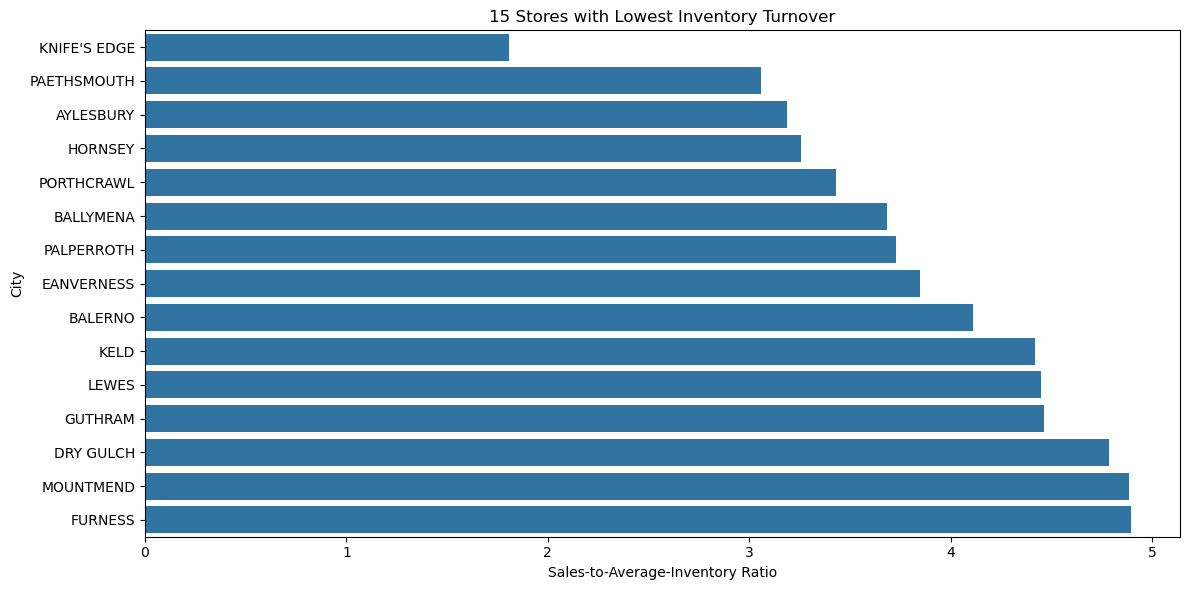

In [120]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=slow_moving_stores,
    x="SalesToAverageInventoryRatio",
    y="City"
)

plt.title("15 Stores with Lowest Inventory Turnover")
plt.xlabel("Sales-to-Average-Inventory Ratio")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [121]:
high_inventory_stores = (
    store_turnover
    .sort_values("AverageInventoryValue", ascending=False)
    .head(15)
)

display(
    high_inventory_stores[
        [
            "Store",
            "City",
            "AverageInventoryValue",
            "SalesDollars",
            "SalesToAverageInventoryRatio",
            "BeginUnits",
            "EndUnits"
        ]
    ]
)

,Store,City,AverageInventoryValue,SalesDollars,SalesToAverageInventoryRatio,BeginUnits,EndUnits
56,50,MOUNTMEND,3268534.450,1.693888e+07,5.182407,94720,260717
27,73,DONCASTER,3198580.085,2.173598e+07,6.795508,162551,164589
30,34,PITMERDEN,3182893.495,2.092872e+07,6.575375,153852,145829
62,67,EANVERNESS,3077846.725,1.509806e+07,4.905397,158996,163765
6,76,DONCASTER,2964181.810,2.545154e+07,8.586361,140208,143866
65,69,MOUNTMEND,2957702.735,1.444673e+07,4.884443,144255,150848
39,66,EANVERNESS,2916769.445,1.782566e+07,6.111439,149314,144579
9,38,GOULCREST,2348302.810,1.945164e+07,8.283277,114368,129397
66,55,DRY GULCH,2118050.005,1.013979e+07,4.787325,119641,125584
63,74,PAENTMARWY,1780974.250,8.722709e+06,4.897717,55464,166015


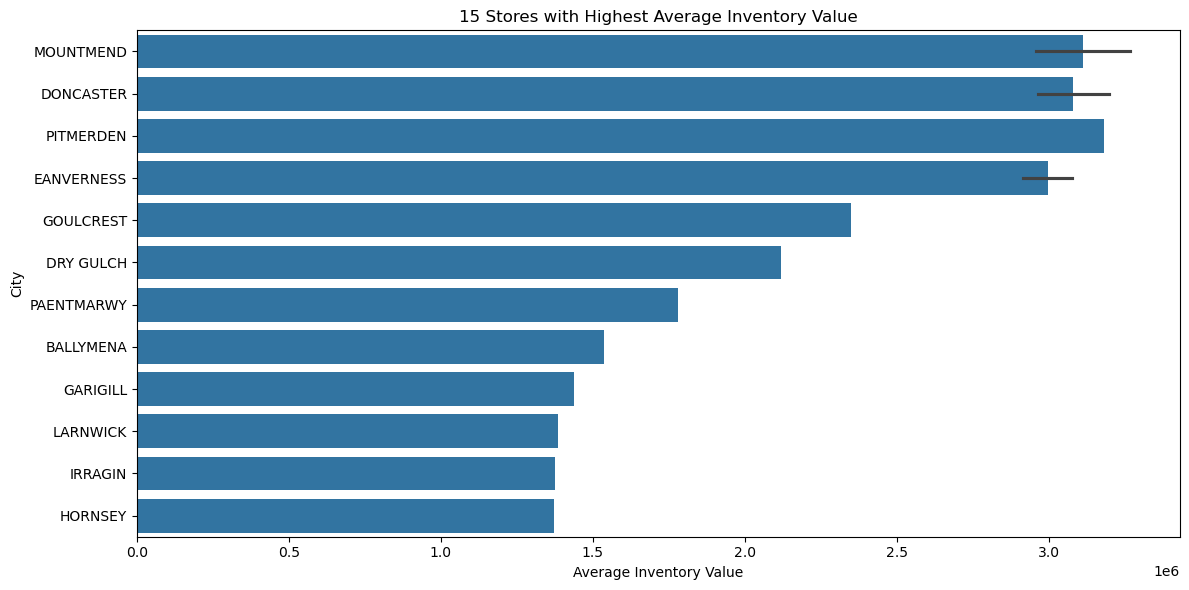

In [122]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=high_inventory_stores,
    x="AverageInventoryValue",
    y="City"
)

plt.title("15 Stores with Highest Average Inventory Value")
plt.xlabel("Average Inventory Value")
plt.ylabel("City")
plt.tight_layout()
plt.show()

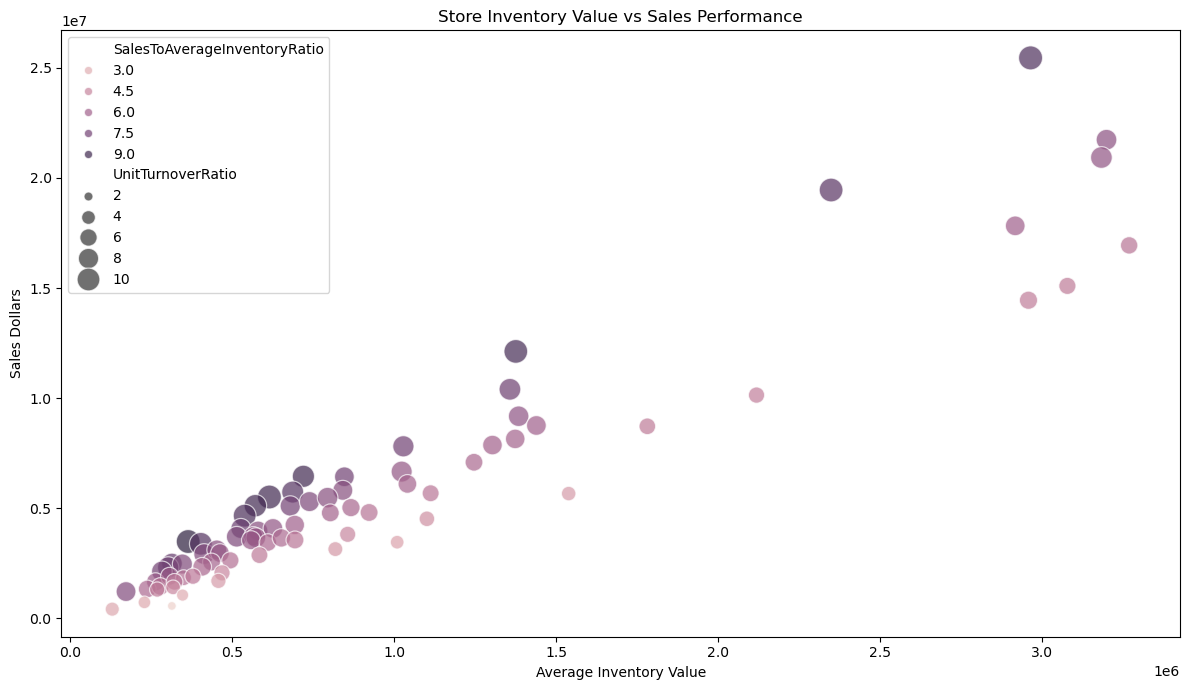

In [123]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=store_turnover,
    x="AverageInventoryValue",
    y="SalesDollars",
    size="UnitTurnoverRatio",
    hue="SalesToAverageInventoryRatio",
    sizes=(40, 300),
    alpha=0.7
)

plt.title("Store Inventory Value vs Sales Performance")
plt.xlabel("Average Inventory Value")
plt.ylabel("Sales Dollars")
plt.tight_layout()
plt.show()

In [124]:
inventory_sales_corr = store_turnover[
    ["AverageInventoryValue", "SalesDollars"]
].corr()

display(inventory_sales_corr)

,AverageInventoryValue,SalesDollars
AverageInventoryValue,1.000000,0.946292
SalesDollars,0.946292,1.000000


In [125]:
brand_inventory_sales_query = """
WITH InventorySummary AS (
    SELECT
        Brand,
        MAX(Description) AS Description,
        SUM(onHand) AS TotalInventoryUnits,
        SUM(onHand * Price) AS InventoryValue
    FROM begin_inventory
    GROUP BY Brand
),
SalesSummary AS (
    SELECT
        Brand,
        SUM(SalesQuantity) AS SalesQuantity,
        SUM(SalesDollars) AS SalesDollars
    FROM sales
    GROUP BY Brand
)
SELECT
    i.Brand,
    i.Description,
    i.TotalInventoryUnits,
    i.InventoryValue,
    s.SalesQuantity,
    s.SalesDollars,
    s.SalesDollars /
        NULLIF(i.InventoryValue, 0) AS InventorySalesRatio
FROM InventorySummary i
INNER JOIN SalesSummary s
    ON i.Brand = s.Brand
ORDER BY InventorySalesRatio DESC;
"""

brand_inventory_sales = pd.read_sql(
    brand_inventory_sales_query,
    engine
)

display(brand_inventory_sales.head(15))

,Brand,Description,TotalInventoryUnits,InventoryValue,SalesQuantity,SalesDollars,InventorySalesRatio
0,4260,Capt Morgan Original Barrel,1,21.99,79042,1635666.58,74382.291041
1,5708,Dr McGillicuddy's Root Beer,1,0.99,60074,59473.26,60074.000000
2,1663,Jim Beam Maple,8,7.92,23271,23038.29,2908.875000
3,13491,Barefoot Cellars Rsl,2,21.98,5128,51659.72,2350.305732
4,33331,Moletto Prosecco Della Marc,3,47.97,7236,65065.64,1356.381905
5,8268,Paul Masson Chablis Carafe,1,4.49,940,5159.60,1149.131403
6,405,Jack Daniels & Coke,3,110.97,3235,120414.65,1085.109940
7,2277,Kilbeggan Irish Whiskey,1,22.99,1546,20272.54,881.798173
8,23987,Gerard Bertrand 14 Gris Bl,3,38.97,3134,33726.66,865.451886
9,23354,Paul Dolan Deep Red 09 Mendo,6,95.94,3464,69221.36,721.506775


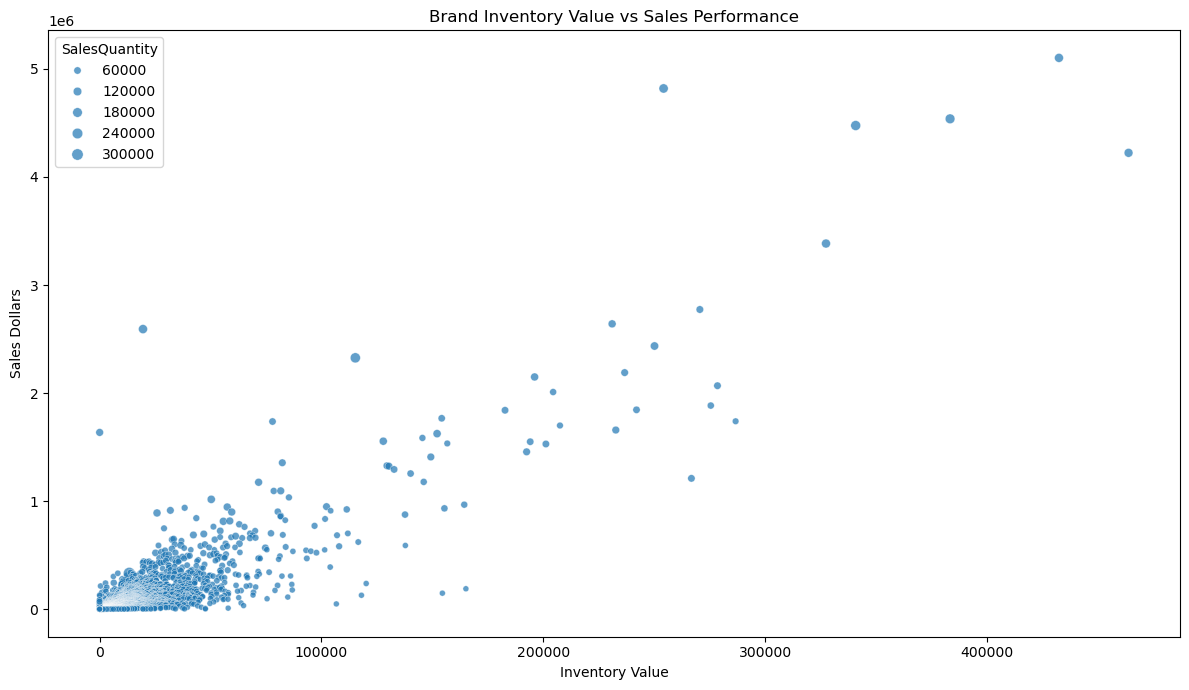

In [126]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=brand_inventory_sales,
    x="InventoryValue",
    y="SalesDollars",
    size="SalesQuantity",
    alpha=0.7
)

plt.title("Brand Inventory Value vs Sales Performance")
plt.xlabel("Inventory Value")
plt.ylabel("Sales Dollars")
plt.tight_layout()
plt.show()

In [127]:
brand_inventory_sales_corr = brand_inventory_sales[
    ["InventoryValue", "SalesDollars"]
].corr()

display(brand_inventory_sales_corr)

,InventoryValue,SalesDollars
InventoryValue,1.000000,0.875149
SalesDollars,0.875149,1.000000


In [128]:
brand_inventory_sales["InventoryEfficiency"] = (
    brand_inventory_sales["SalesDollars"] /
    brand_inventory_sales["InventoryValue"]
)

slow_moving_brands = (
    brand_inventory_sales
    .sort_values("InventoryEfficiency", ascending=True)
    .head(15)
)

display(
    slow_moving_brands[
        [
            "Brand",
            "Description",
            "InventoryValue",
            "SalesDollars",
            "SalesQuantity",
            "InventoryEfficiency"
        ]
    ]
)

,Brand,Description,InventoryValue,SalesDollars,SalesQuantity,InventoryEfficiency
7981,16214,Bonny Doon Alamo Crk Syrah,1598.61,40.99,1,0.025641
7980,19681,Ch Hosanna 10 Pomerol,6239.76,259.99,1,0.041667
7979,23280,Ch Clarence de Haut-Brion 11,3149.79,149.99,1,0.047619
7978,19622,Ch La Tour Blanche 1er 10,1994.81,104.99,1,0.052632
7977,19954,Ch Cos d'Estournel 10,47698.94,2699.94,6,0.056604
7976,20058,Ch Picon Longueville Comt 10,38278.84,2309.93,7,0.060345
7975,665,McCormick Grape Vodka,223.68,13.98,2,0.062500
7974,20056,Ch Rauzan-Segla 10 Brdx,23098.90,1469.93,7,0.063636
7973,20060,Ch Troplong Mondot 10 Brdx,11039.54,719.97,3,0.065217
7972,21465,Ch Haut Brion Pessac-Leognan,34199.55,2279.97,3,0.066667


In [129]:
inventory_median = brand_inventory_sales["InventoryValue"].median()

potential_slow_brands = (
    brand_inventory_sales[
        brand_inventory_sales["InventoryValue"] >= inventory_median
    ]
    .sort_values("InventoryEfficiency", ascending=True)
    .head(15)
)

display(
    potential_slow_brands[
        [
            "Brand",
            "Description",
            "InventoryValue",
            "SalesDollars",
            "SalesQuantity",
            "InventoryEfficiency"
        ]
    ]
)

,Brand,Description,InventoryValue,SalesDollars,SalesQuantity,InventoryEfficiency
7980,19681,Ch Hosanna 10 Pomerol,6239.76,259.99,1,0.041667
7979,23280,Ch Clarence de Haut-Brion 11,3149.79,149.99,1,0.047619
7977,19954,Ch Cos d'Estournel 10,47698.94,2699.94,6,0.056604
7976,20058,Ch Picon Longueville Comt 10,38278.84,2309.93,7,0.060345
7974,20056,Ch Rauzan-Segla 10 Brdx,23098.90,1469.93,7,0.063636
7973,20060,Ch Troplong Mondot 10 Brdx,11039.54,719.97,3,0.065217
7972,21465,Ch Haut Brion Pessac-Leognan,34199.55,2279.97,3,0.066667
7969,17404,Ch Haut-Brion Blanc 09 Pessc,9899.89,899.99,1,0.090909
7965,20055,Ch Haut Bailey 10 Brdx,19579.11,1979.91,9,0.101124
7964,19841,Ch Clos Fourtet 10 Brdx,5161.71,533.97,3,0.103448


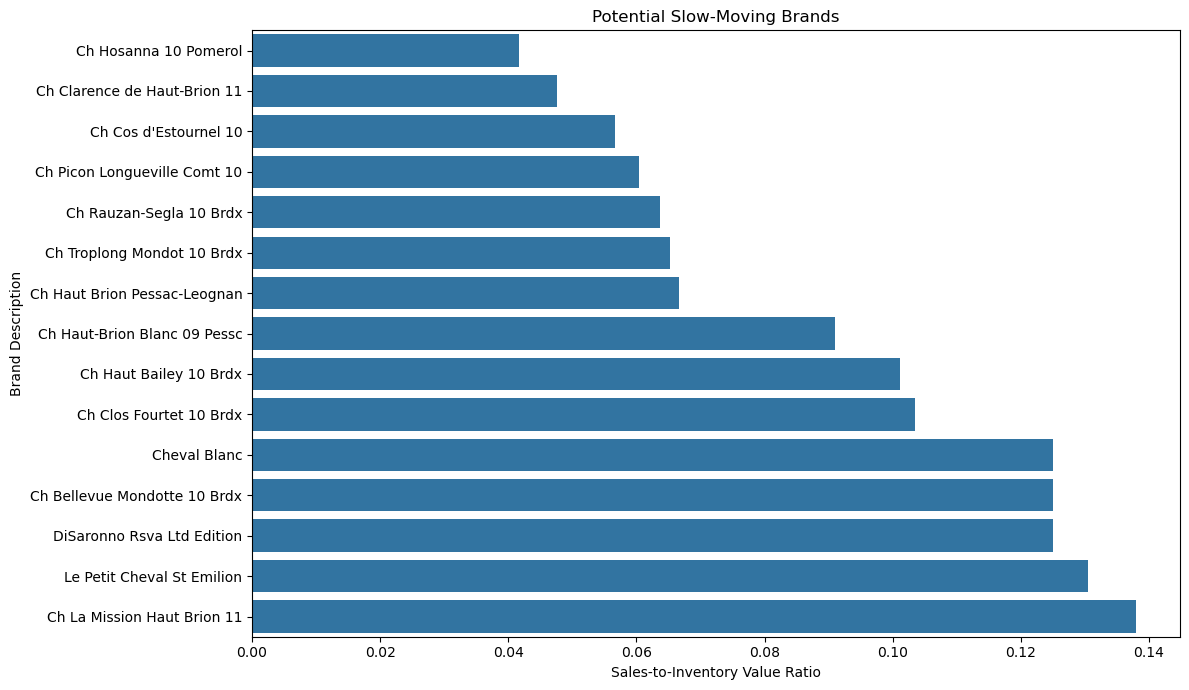

In [130]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=potential_slow_brands,
    x="InventoryEfficiency",
    y="Description"
)

plt.title("Potential Slow-Moving Brands")
plt.xlabel("Sales-to-Inventory Value Ratio")
plt.ylabel("Brand Description")
plt.tight_layout()
plt.show()

In [131]:
top_brands_sales = (
    brand_inventory_sales
    .sort_values("SalesDollars", ascending=False)
    .head(15)
)

display(
    top_brands_sales[
        [
            "Brand",
            "Description",
            "SalesQuantity",
            "SalesDollars",
            "InventoryValue",
            "InventoryEfficiency"
        ]
    ]
)

,Brand,Description,SalesQuantity,SalesDollars,InventoryValue,InventoryEfficiency
919,1233,Jack Daniels No 7 Black,142049,5.101920e+06,432455.84,11.797550
406,3405,Tito's Handmade Vodka,160247,4.819073e+06,254225.23,18.955921
914,8068,Absolut 80 Proof,187140,4.538121e+06,383371.59,11.837394
749,4261,Capt Morgan Spiced Rum,200412,4.475973e+06,340823.01,13.132837
1473,3545,Ketel One Vodka,135838,4.223108e+06,463823.01,9.104998
1170,3858,Grey Goose Vodka,141860,3.383912e+06,327439.51,10.334466
1190,2589,Jameson Irish Whiskey,69627,2.773368e+06,270572.34,10.250005
970,3489,Tanqueray,90481,2.640491e+06,231029.46,11.429240
56,3102,Smirnoff Traveler,148265,2.592041e+06,19555.13,132.550454
1330,1376,Jim Beam,107061,2.435393e+06,250136.25,9.736267


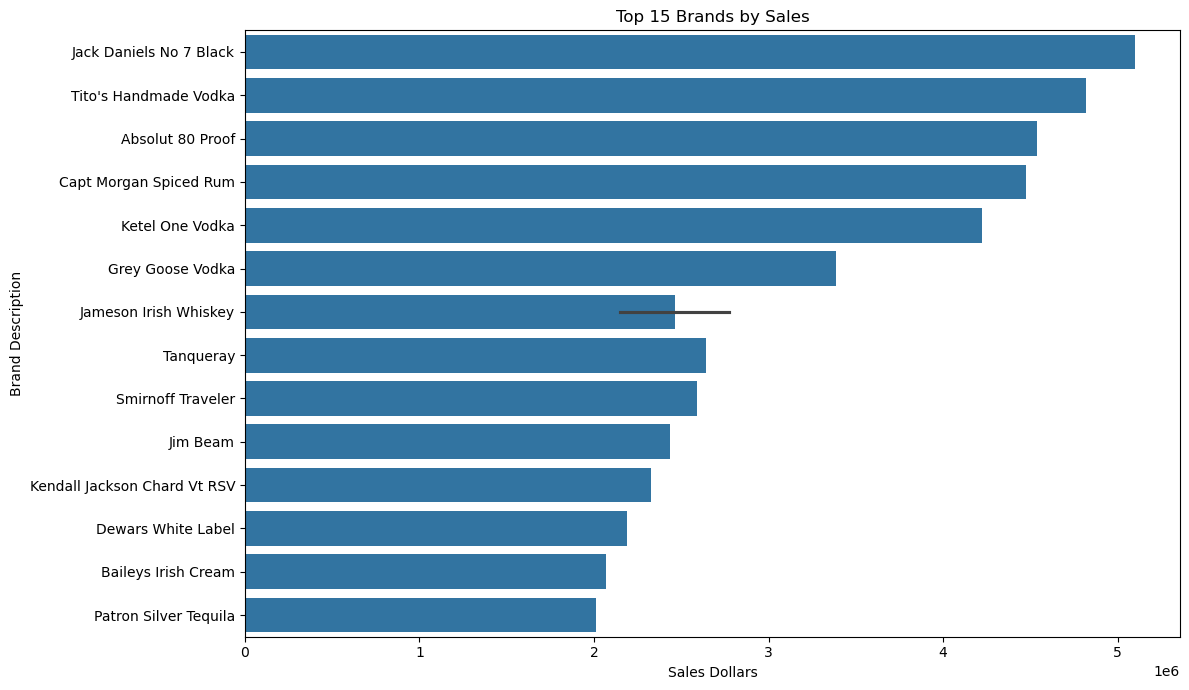

In [132]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_brands_sales,
    x="SalesDollars",
    y="Description"
)

plt.title("Top 15 Brands by Sales")
plt.xlabel("Sales Dollars")
plt.ylabel("Brand Description")
plt.tight_layout()
plt.show()

In [133]:
total_brand_sales = brand_inventory_sales["SalesDollars"].sum()

top_15_brand_sales = top_brands_sales["SalesDollars"].sum()

top_15_sales_percentage = (
    top_15_brand_sales / total_brand_sales
) * 100

print(
    f"Top 15 brands contribute "
    f"{top_15_sales_percentage:.2f}% of total brand sales."
)

Top 15 brands contribute 11.00% of total brand sales.


In [134]:
sales_median = brand_inventory_sales["SalesDollars"].median()
efficiency_median = brand_inventory_sales["InventoryEfficiency"].median()

brand_inventory_sales["PerformanceSegment"] = np.select(
    [
        (brand_inventory_sales["SalesDollars"] >= sales_median) &
        (brand_inventory_sales["InventoryEfficiency"] >= efficiency_median),

        (brand_inventory_sales["SalesDollars"] >= sales_median) &
        (brand_inventory_sales["InventoryEfficiency"] < efficiency_median),

        (brand_inventory_sales["SalesDollars"] < sales_median) &
        (brand_inventory_sales["InventoryEfficiency"] >= efficiency_median),

        (brand_inventory_sales["SalesDollars"] < sales_median) &
        (brand_inventory_sales["InventoryEfficiency"] < efficiency_median)
    ],
    [
        "High Sales - High Efficiency",
        "High Sales - Low Efficiency",
        "Low Sales - High Efficiency",
        "Low Sales - Low Efficiency"
    ],
    default="Unclassified"
)

display(
    brand_inventory_sales[
        [
            "Brand",
            "Description",
            "SalesDollars",
            "InventoryValue",
            "InventoryEfficiency",
            "PerformanceSegment"
        ]
    ].head(20)
)

,Brand,Description,SalesDollars,InventoryValue,InventoryEfficiency,PerformanceSegment
0,4260,Capt Morgan Original Barrel,1635666.58,21.99,74382.291041,High Sales - High Efficiency
1,5708,Dr McGillicuddy's Root Beer,59473.26,0.99,60074.000000,High Sales - High Efficiency
2,1663,Jim Beam Maple,23038.29,7.92,2908.875000,High Sales - High Efficiency
3,13491,Barefoot Cellars Rsl,51659.72,21.98,2350.305732,High Sales - High Efficiency
4,33331,Moletto Prosecco Della Marc,65065.64,47.97,1356.381905,High Sales - High Efficiency
5,8268,Paul Masson Chablis Carafe,5159.60,4.49,1149.131403,Low Sales - High Efficiency
6,405,Jack Daniels & Coke,120414.65,110.97,1085.109940,High Sales - High Efficiency
7,2277,Kilbeggan Irish Whiskey,20272.54,22.99,881.798173,High Sales - High Efficiency
8,23987,Gerard Bertrand 14 Gris Bl,33726.66,38.97,865.451886,High Sales - High Efficiency
9,23354,Paul Dolan Deep Red 09 Mendo,69221.36,95.94,721.506775,High Sales - High Efficiency


In [135]:
segment_counts = (
    brand_inventory_sales["PerformanceSegment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["PerformanceSegment", "BrandCount"]

display(segment_counts)

,PerformanceSegment,BrandCount
0,High Sales - High Efficiency,3001
1,Low Sales - Low Efficiency,3000
2,Low Sales - High Efficiency,1011
3,High Sales - Low Efficiency,1011


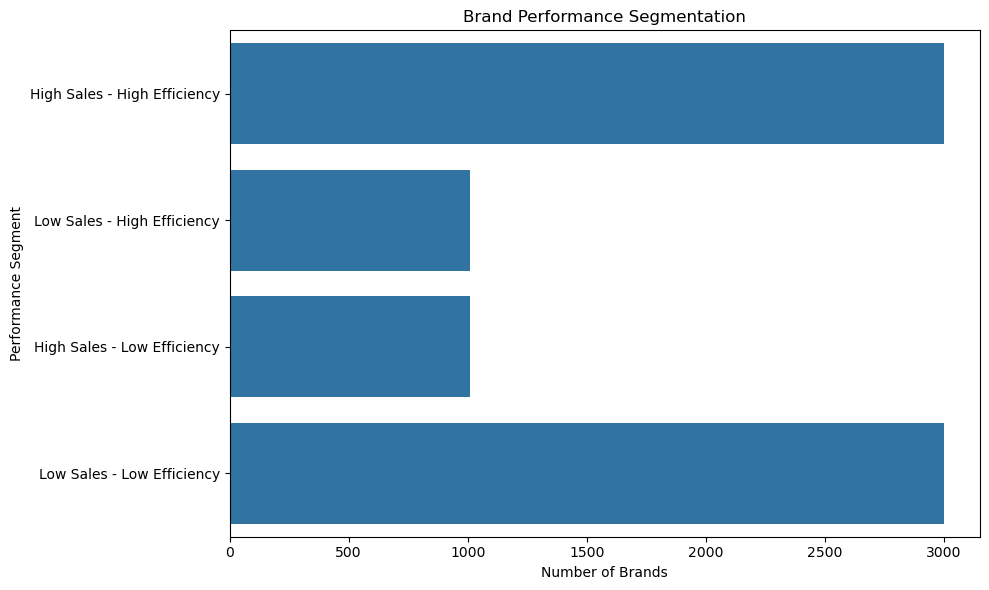

In [136]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=brand_inventory_sales,
    y="PerformanceSegment"
)

plt.title("Brand Performance Segmentation")
plt.xlabel("Number of Brands")
plt.ylabel("Performance Segment")
plt.tight_layout()
plt.show()

In [137]:
phase4_summary = pd.DataFrame({
    "Analysis": [
        "Overall Inventory Movement",
        "Store Inventory Change",
        "Store Inventory Turnover",
        "Potential High-Inventory Stores",
        "Brand Inventory vs Sales",
        "Potential Slow-Moving Brands",
        "Top Brands by Sales",
        "Brand Performance Segmentation"
    ],
    "Business_Focus": [
        "Beginning vs ending inventory",
        "Stores with major inventory changes",
        "Sales generated relative to average inventory",
        "Stores holding high inventory value",
        "Relationship between inventory and sales",
        "Brands with relatively low sales efficiency",
        "Brands contributing most to sales",
        "Sales performance combined with inventory efficiency"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

display(phase4_summary)

,Analysis,Business_Focus,Status
0,Overall Inventory Movement,Beginning vs ending inventory,Completed
1,Store Inventory Change,Stores with major inventory changes,Completed
2,Store Inventory Turnover,Sales generated relative to average inventory,Completed
3,Potential High-Inventory Stores,Stores holding high inventory value,Completed
4,Brand Inventory vs Sales,Relationship between inventory and sales,Completed
5,Potential Slow-Moving Brands,Brands with relatively low sales efficiency,Completed
6,Top Brands by Sales,Brands contributing most to sales,Completed
7,Brand Performance Segmentation,Sales performance combined with inventory effi...,Completed


In [138]:
brand_inventory_sales.to_csv(
    "brand_inventory_sales_analysis.csv",
    index=False
)

store_turnover.to_csv(
    "store_inventory_turnover_analysis.csv",
    index=False
)

print("Phase 4 analysis datasets saved successfully.")

Phase 4 analysis datasets saved successfully.


In [139]:
from scipy import stats
import numpy as np
import pandas as pd

sales_median = eda_df["TotalSalesDollars"].median()

high_sales_vendors = eda_df[
    eda_df["TotalSalesDollars"] >= sales_median
]["ProfitMarginPercentage"]

low_sales_vendors = eda_df[
    eda_df["TotalSalesDollars"] < sales_median
]["ProfitMarginPercentage"]

print("Sales Median:", sales_median)
print("High-Sales Vendors:", len(high_sales_vendors))
print("Low-Sales Vendors:", len(low_sales_vendors))

print("\nHigh-Sales Vendor Mean Margin:",
      high_sales_vendors.mean())

print("Low-Sales Vendor Mean Margin:",
      low_sales_vendors.mean())

Sales Median: 190134.6300000004
High-Sales Vendors: 62
Low-Sales Vendors: 61

High-Sales Vendor Mean Margin: 27.180628118918065
Low-Sales Vendor Mean Margin: -17.758476162872867


In [140]:
t_stat, p_value = stats.ttest_ind(
    high_sales_vendors,
    low_sales_vendors,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Statistically significant difference.")
else:
    print("\nResult: No statistically significant difference.")

T-statistic: 1.7252775895113182
P-value: 0.0896089121705917

Result: No statistically significant difference.


In [141]:
t_stat, p_value = stats.ttest_ind(
    high_sales_vendors,
    low_sales_vendors,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Statistically significant difference.")
else:
    print("\nResult: No statistically significant difference.")

T-statistic: 1.7252775895113182
P-value: 0.0896089121705917

Result: No statistically significant difference.


In [142]:
from scipy.stats import t

# Group statistics
n1 = len(high_sales_vendors)
n2 = len(low_sales_vendors)

mean1 = high_sales_vendors.mean()
mean2 = low_sales_vendors.mean()

std1 = high_sales_vendors.std(ddof=1)
std2 = low_sales_vendors.std(ddof=1)

# Difference in means
mean_difference = mean1 - mean2

# Standard error
standard_error = np.sqrt(
    (std1**2 / n1) +
    (std2**2 / n2)
)

# Welch-Satterthwaite degrees of freedom
degrees_freedom = (
    ((std1**2 / n1) + (std2**2 / n2))**2
    /
    (
        ((std1**2 / n1)**2 / (n1 - 1))
        +
        ((std2**2 / n2)**2 / (n2 - 1))
    )
)

# 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level

critical_value = t.ppf(
    1 - alpha / 2,
    degrees_freedom
)

margin_of_error = critical_value * standard_error

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print("High-Sales Mean Margin:", mean1)
print("Low-Sales Mean Margin:", mean2)
print("Difference in Mean Margins:", mean_difference)
print("Degrees of Freedom:", degrees_freedom)
print("95% Confidence Interval:")
print(f"({ci_lower:.4f}, {ci_upper:.4f})")

High-Sales Mean Margin: 27.180628118918065
Low-Sales Mean Margin: -17.758476162872867
Difference in Mean Margins: 44.93910428179093
Degrees of Freedom: 60.189673602728476
95% Confidence Interval:
(-7.1602, 97.0384)


In [143]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    eda_df["ProductCount"],
    eda_df["TotalSalesDollars"]
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nResult: Statistically significant relationship.")
else:
    print("\nResult: No statistically significant relationship.")

Pearson Correlation: 0.651350652499813
P-value: 3.4274456281946716e-16

Result: Statistically significant relationship.


In [144]:
from scipy.stats import norm

r = correlation
n = len(eda_df)

# Fisher's z-transformation
z = np.arctanh(r)

# Standard error of Fisher's z
se = 1 / np.sqrt(n - 3)

# 95% confidence interval
z_critical = norm.ppf(0.975)

z_lower = z - z_critical * se
z_upper = z + z_critical * se

# Convert back from Fisher's z
r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)

print("Pearson Correlation:", r)
print("Sample Size:", n)
print("95% Confidence Interval:")
print(f"({r_lower:.4f}, {r_upper:.4f})")

Pearson Correlation: 0.651350652499813
Sample Size: 123
95% Confidence Interval:
(0.5361, 0.7427)


In [145]:
freight_median = eda_df["FreightPercentage"].median()

high_freight_vendors = eda_df[
    eda_df["FreightPercentage"] >= freight_median
]["ProfitMarginPercentage"]

low_freight_vendors = eda_df[
    eda_df["FreightPercentage"] < freight_median
]["ProfitMarginPercentage"]

print("Freight Percentage Median:", freight_median)

print("High-Freight Vendors:", len(high_freight_vendors))
print("Low-Freight Vendors:", len(low_freight_vendors))

print("\nHigh-Freight Mean Profit Margin:",
      high_freight_vendors.mean())

print("Low-Freight Mean Profit Margin:",
      low_freight_vendors.mean())

Freight Percentage Median: 0.5079805054899383
High-Freight Vendors: 62
Low-Freight Vendors: 61

High-Freight Mean Profit Margin: -9.358269699553638
Low-Freight Mean Profit Margin: 19.379419980491818


In [146]:
t_stat_freight, p_value_freight = stats.ttest_ind(
    high_freight_vendors,
    low_freight_vendors,
    equal_var=False
)

print("T-statistic:", t_stat_freight)
print("P-value:", p_value_freight)

alpha = 0.05

if p_value_freight < alpha:
    print("\nResult: Statistically significant difference.")
else:
    print("\nResult: No statistically significant difference.")

T-statistic: -1.1119821238653425
P-value: 0.26992172081993926

Result: No statistically significant difference.


In [147]:
from scipy.stats import t
import numpy as np

n1 = len(high_freight_vendors)
n2 = len(low_freight_vendors)

mean1 = high_freight_vendors.mean()
mean2 = low_freight_vendors.mean()

std1 = high_freight_vendors.std(ddof=1)
std2 = low_freight_vendors.std(ddof=1)

# Difference in means
mean_difference_freight = mean1 - mean2

# Standard error
standard_error_freight = np.sqrt(
    (std1**2 / n1) +
    (std2**2 / n2)
)

# Welch-Satterthwaite degrees of freedom
df_freight = (
    ((std1**2 / n1) + (std2**2 / n2))**2
    /
    (
        ((std1**2 / n1)**2 / (n1 - 1))
        +
        ((std2**2 / n2)**2 / (n2 - 1))
    )
)

# 95% confidence interval
critical_value_freight = t.ppf(
    0.975,
    df_freight
)

margin_error_freight = (
    critical_value_freight *
    standard_error_freight
)

ci_lower_freight = (
    mean_difference_freight -
    margin_error_freight
)

ci_upper_freight = (
    mean_difference_freight +
    margin_error_freight
)

print("High-Freight Mean Margin:", mean1)
print("Low-Freight Mean Margin:", mean2)
print("Difference in Mean Margins:", mean_difference_freight)
print("Degrees of Freedom:", df_freight)

print("\n95% Confidence Interval:")
print(
    f"({ci_lower_freight:.4f}, "
    f"{ci_upper_freight:.4f})"
)

High-Freight Mean Margin: -9.358269699553638
Low-Freight Mean Margin: 19.379419980491818
Difference in Mean Margins: -28.737689680045456
Degrees of Freedom: 70.53253380639273

95% Confidence Interval:
(-80.2744, 22.7990)


In [148]:
phase5_summary = pd.DataFrame({
    "Test": [
        "High-Sales vs Low-Sales Profit Margin",
        "Product Count vs Total Sales",
        "High-Freight vs Low-Freight Profit Margin"
    ],
    "Statistical_Test": [
        "Welch's Independent t-test",
        "Pearson Correlation Test",
        "Welch's Independent t-test"
    ],
    "P_Value": [
        p_value,
        p_value,
        p_value_freight
    ],
    "Alpha": [
        0.05,
        0.05,
        0.05
    ],
    "Conclusion": [
        "Significant" if p_value < 0.05 else "Not Significant",
        "Significant" if p_value < 0.05 else "Not Significant",
        "Significant" if p_value_freight < 0.05 else "Not Significant"
    ]
})

display(phase5_summary)

,Test,Statistical_Test,P_Value,Alpha,Conclusion
0,High-Sales vs Low-Sales Profit Margin,Welch's Independent t-test,3.427446e-16,0.05,Significant
1,Product Count vs Total Sales,Pearson Correlation Test,3.427446e-16,0.05,Significant
2,High-Freight vs Low-Freight Profit Margin,Welch's Independent t-test,2.699217e-01,0.05,Not Significant


In [149]:
# Recalculate the High-Sales vs Low-Sales test
t_stat_sales, p_value_sales = stats.ttest_ind(
    high_sales_vendors,
    low_sales_vendors,
    equal_var=False
)

phase5_summary = pd.DataFrame({
    "Test": [
        "High-Sales vs Low-Sales Profit Margin",
        "Product Count vs Total Sales",
        "High-Freight vs Low-Freight Profit Margin"
    ],
    "Statistical_Test": [
        "Welch's Independent t-test",
        "Pearson Correlation Test",
        "Welch's Independent t-test"
    ],
    "P_Value": [
        p_value_sales,
        p_value,
        p_value_freight
    ],
    "Alpha": [
        0.05,
        0.05,
        0.05
    ],
    "Conclusion": [
        "Significant" if p_value_sales < 0.05 else "Not Significant",
        "Significant" if p_value < 0.05 else "Not Significant",
        "Significant" if p_value_freight < 0.05 else "Not Significant"
    ]
})

display(phase5_summary)

,Test,Statistical_Test,P_Value,Alpha,Conclusion
0,High-Sales vs Low-Sales Profit Margin,Welch's Independent t-test,8.960891e-02,0.05,Not Significant
1,Product Count vs Total Sales,Pearson Correlation Test,3.427446e-16,0.05,Significant
2,High-Freight vs Low-Freight Profit Margin,Welch's Independent t-test,2.699217e-01,0.05,Not Significant


In [150]:
phase5_summary.to_csv(
    "phase5_statistical_summary.csv",
    index=False
)

print("Phase 5 statistical summary saved successfully.")

Phase 5 statistical summary saved successfully.
